# Predictive Modeling of Obesity Risk for AI Assisted Clinical Decision Support

---------------------------------------------------------

#### *References are listed at the end of the notebook*

---------------------------------------------------------

### End-to-End Project Summary (Phases II–IV)

### Section 1 - Data Engineering

* Extracted BRFSS data from fixed-width .asc files using SAS label mappings  
* Parsed and structured variables into a Pandas DataFrame  
* Selected relevant predictors from 300+ variables based on behavioral, health, demographic, and socioeconomic domains  
* Encoded variables to convert them from survey labeling to usable numerical data  
* Recalculated BMI and defined a binary obesity target (BMI ≥ 30)  
* Removed height and weight variables to prevent data leakage  

---

### Section 2 – Exploratory Data Analysis (EDA)

* Assessed dataset structure, distributions, and missingness patterns  
* Computed descriptive statistics (means, medians, correlations)  
* Generated multiple visualization types (bar plots, box plots, heatmaps)  
* Evaluated obesity prevalence across demographic, behavioral, and socioeconomic subgroups  
* Identified potential outliers and anomalies  
* Documented key insights to guide feature selection and modeling decisions  

---

### Section 3 – Data Cleaning & Feature Engineering

* Pruned high-missing and redundant variables  
* Evaluated missingness and structural sparsity across features  
* Categorized variables into numerical, categorical, and binary types  
* Prepared feature groupings for pipeline-based preprocessing using ColumnTransformer  

---

### Section 4 – Modeling and Evaluation

* Split data into training and testing sets  
* Built preprocessing pipelines using ColumnTransformer for scaling, encoding, and imputation  
* Trained multiple models including Logistic Regression and Gradient Boosting  
* Evaluated models using accuracy, precision, recall, F1 score, and ROC AUC  
* Compared base and tuned model performance  
* Selected Logistic Regression as the final model due to stronger recall and F1 performance, aligning with the goal of identifying at-risk individuals  
* Interpreted model behavior using feature importance (coefficients) and permutation importance  

---

### Section 5 – Model Deployment & System Design

* Designed an end-to-end system to simulate real-world deployment of the model  
* Implemented an interactive input interface to simulate clinician data entry (frontend mockup)  
* Developed mapping functions to translate user inputs into encoded feature values based on the original dataset  
* Built a backend processing pipeline to pass encoded inputs through the trained model  
* Generated real-time predictions and probability scores for individual patients  

---

### Section 6 – API & Application Simulation

* Implemented a function-based API to simulate backend model deployment  
* Designed the API to accept structured patient input and return prediction outputs  
* Demonstrated how the model could be integrated into external systems such as clinical tools or electronic health records  
* Provided example API usage with a sample patient input to illustrate real-world interaction    

---

### Section 7 – Monitoring and Maintenance

* Outlined strategies for tracking model performance over time using evaluation metrics  
* Considered the impact of data drift and changing population characteristics  
* Proposed periodic retraining using updated data  
* Highlighted the importance of ongoing monitoring to maintain model reliability and clinical usefulness  

---

### Section 8 – Bias, Fairness, and Ethical Considerations

* Evaluated potential sources of bias related to demographic and socioeconomic features  
* Considered how structural inequalities may influence model predictions  
* Acknowledged potential differences in model performance across subgroups  
* Emphasized the importance of human oversight and clinical judgment in interpreting model outputs

---

### Section 9 – Explainable AI (XAI)

* Generated global explanations using model coefficients to understand overall feature importance  
* Implemented local explanations by calculating feature-level contributions for individual predictions  
* Identified top contributing factors for each prediction to improve interpretability  
* Added a simple reasoning layer that provides a short clinical interpretation alongside predictions

In [ ]:
#load initial libraries and modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Section 1: Data Engineering

In [ ]:
#define pathways directly to the files

data_path = "raw_data.asc"
labels_path = "variable_labels.sas"

import os
print(os.path.exists(data_path), data_path)
print(os.path.exists(labels_path), labels_path)

True raw_data.asc
True variable_labels.sas


In [ ]:
#load only the chosen variables
#these variables were chosen from the intial 300+ becasue they directly relate to health,
#lifestyle, and

variables_chosen = ["_BMI5", #target
                    #demographics
                    "WEIGHT2", "SEXVAR", "HEIGHT3", "_AGEG5YR",
                    "MARITAL","_RACEGR3", "_URBSTAT",
                    "_STATE",
                    #socioeconomic
                    "EDUCA", "_EDUCAG", "INCOME3",
                    "_INCOMG1", "EMPLOY1", "RENTHOM1",
                    "FOODSTMP", "SDHBILLS", "SDHFOOD1",
                    "SDHEMPLY", "MEDCOST1",
                    #behavior/lifestyle
                    "EXERANY2", "_TOTINDA","SSBFRUT3", "SSBSUGR2",
                    #substance use
                    "ALCDAY4", "_RFDRHV9",
                    "SMOKE100", "_SMOKER3", "_LCSYSMK",
                    "ECIGNOW3","MARIJAN1",
                    #health
                    "GENHLTH", "_RFHLTH", "MENTHLTH",
                    "_MENT14D", "POORHLTH", "PHYSHLTH",
                    "DIFFWALK", "ASTHMA3", "EMTSUPRT",
                    "LSATISFY",
                    #healthcare
                    "PERSDOC3", "_HLTHPL2", "CHECKUP1","LASTDEN4"
                    ]

#From the initial 300+ variables, the above 46 variables were selected for their
#relevancy to determining obesity. Demographics, socioecominics, lifestyle, health,
#and behavioral are all necessary factors when predicting obesity.

In [ ]:
len(variables_chosen)

45

In [ ]:
#parse the labels doc to get the variables

import re

def parse_input(labels_file_path):
    with open(labels_file_path, "r") as f:
        text = f.read()

    m = re.search(r"(?im)^\s*INPUT\b(.*?);", text, flags=re.DOTALL)
    if not m:
        raise ValueError("SAS INPUT statement not found")

    block = m.group(1)

    #this compiles a pattern matching the original SAS formatting to capture each variable name
    line_pat = re.compile(r"""(?mx)
        ^\s*(?P<var>[A-Za-z_][A-Za-z0-9_]*)
        \s+(?P<start>\d+)(?:\s*-\s*(?P<end>\d+))?
        (?:\s*/\*.*?\*/\s*)?$"""
        ) #coding reference no. 1

    col_map = {}

    for m2 in line_pat.finditer(block):
        var = m2.group("var")
        start = int(m2.group("start"))
        end = int(m2.group("end") or start)

        zero_start = start - 1
        zero_end = end
        col_map[var] = (zero_start, zero_end)

    return col_map

In [ ]:
#check to make sure function works

labels_map = parse_input(labels_path)

print(f"Variables found: {len(labels_map)}")
list(labels_map.items())[:10]

Variables found: 301


[('_STATE', (0, 2)),
 ('FMONTH', (16, 18)),
 ('IDATE', (18, 26)),
 ('IMONTH', (18, 20)),
 ('IDAY', (20, 22)),
 ('IYEAR', (22, 26)),
 ('DISPCODE', (31, 35)),
 ('SEQNO', (35, 45)),
 ('_PSU', (35, 45)),
 ('CTELENM1', (62, 63))]

In [ ]:
#load the data from the .asc file into a pandas dataframe

#quick check to make sure all selected variables are being read in
present = [v for v in variables_chosen if v in labels_map]
missing = [v for v in variables_chosen if v not in labels_map]
print("Missing:", missing)

colspecs = [labels_map[v] for v in present]

brfss_raw = pd.read_fwf(data_path,
                        colspecs=colspecs,
                        names=present,
                        dtype=str)

Missing: []


### Variable Encoding:

The selected variables were encoded to transform survey-coded response values into structured, model-ready features. This process removes survey artifacts (e.g., “Don’t know,” “Refused,” and skip logic codes) and standardizes measurement scales to reflect the true conceptual meaning of each variable.

Variable measurement types were determined using the BRFSS 2024 codebook and survey design documentation. Post-encoding classifications reflect true measurement scales (continuous, binary, ordinal, and nominal) following the removal of survey-specific response codes (e.g., 77, 88, 99).

----------------------------------------------------

* **Continuous Numeric:**
WEIGHT2, HEIGHT3, MENTHLTH, POORHLTH, PHYSHLTH, ALCDAY4, SSBFRUT3, SSBSUGR2

* **Binary:**
SEXVAR, EXERANY2, SMOKE100, ASTHMA3, DIFFWALK, _HLTHPL2, MEDCOST1, _RFDRHV9, _RFHLTH, _MENT14D, _TOTINDA

* **Ordinal:**
TARGET, EDUCA, _EDUCAG, LSATISFY, _AGEG5YR, INCOME3, _INCOMG1, GENHLTH, CHECKUP1, LASTDEN4, _SMOKER3, ECIGNOW3

* **Nominal Categorical:**
_STATE, _RACEGR3, MARITAL, EMPLOY1, RENTHOM1, FOODSTMP, SDHBILLS, SDHFOOD1, SDHEMPLY, _URBSTAT, MARIJAN1, EMTSUPRT, PERSDOC3

In [ ]:
#each feature needs to be encoded to convert
#the survey codes to meaningful data

#initialize a new dataframe to add the encoded features to:
brfss_encoded = pd.DataFrame(index=brfss_raw.index)

#starting with the continuous numeric features:

#helper
def _to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

#weight
def encode_weight2_lbs(weight2: pd.Series) -> pd.Series:
    """
    WEIGHT2 encoding:
      0050-0776 => pounds
      9023-9352 => kilograms (leading 9 indicates metric; kg = code - 9000)
      7777, 9999, blanks => NaN
    Output: weight_lbs (float)
    """
    s = _to_num(weight2)

    #missing-like codes
    s = s.replace({7777: np.nan, 9999: np.nan})

    out = pd.Series(np.nan, index=s.index, dtype="float64")

    #pounds
    m_lbs = s.between(50, 776)
    out.loc[m_lbs] = s.loc[m_lbs].astype(float)

    #kilograms: 9xxx -> kg = code - 9000
    m_kg = s.between(9023, 9352)
    kg = (s.loc[m_kg] - 9000).astype(float)
    out.loc[m_kg] = kg * 2.2046226218  # kg -> lbs

    return out

#height
def encode_height3_inches(height3: pd.Series) -> pd.Series:
    """
    HEIGHT3 encoding:
      0200-0711 => feet/inches encoded as FII (e.g., 511 = 5'11")
                   feet = code // 100, inches = code % 100
      9061-9998 => meters/centimeters encoded as 9MCC (e.g., 9061 = 0? actually 9 + meters + centimeters)
                   interpretation: meters = (code // 100) % 10, cm = code % 100
                   total_cm = meters*100 + cm
      7777, 9999, blanks => NaN
    Output: height_in (float)
    """
    s = _to_num(height3)
    s = s.replace({7777: np.nan, 9999: np.nan})

    out = pd.Series(np.nan, index=s.index, dtype="float64")

    #feet/inches
    m_ftin = s.between(200, 711)
    ftin = s.loc[m_ftin].astype(int)
    ft = (ftin // 100).astype(float)
    inch = (ftin % 100).astype(float)

    #basic validity: inches should be 0-11
    valid_in = inch.between(0, 11)
    out.loc[m_ftin] = np.where(valid_in, ft * 12 + inch, np.nan)

    #metric: 9MCC, meters is the hundreds digit after leading 9
    m_metric = s.between(9061, 9998)
    metric = s.loc[m_metric].astype(int)
    meters = ((metric // 100) % 10).astype(float)  # 9MCC -> M
    cm = (metric % 100).astype(float)              # 9MCC -> CC
    total_cm = meters * 100 + cm

    #check: centimeters should be 0-99; meters reasonable 0-9
    valid_metric = cm.between(0, 99) & meters.between(0, 9)
    inches = total_cm / 2.54
    out.loc[m_metric] = np.where(valid_metric, inches, np.nan)

    return out

#mental health
def encode_days_0_30(var: pd.Series) -> pd.Series:
    """
    For MENTHLTH / POORHLTH / PHYSHLTH:
      1-30 => days
      88 => 0
      77, 99, blanks => NaN
    Output: days (float)
    """
    s = _to_num(var)
    s = s.replace({77: np.nan, 99: np.nan, 88: 0})
    #keep only 0-30
    s = s.where(s.between(0, 30), np.nan)
    return s.astype(float)

#alcoholic drinks per week
def encode_alc_days_per_week(alcd: pd.Series) -> pd.Series:
    """
    ALCDAY4 encoding:
      1XX => days per week (XX)
      2XX => days per 30 days (XX / 4)
      888 => 0
      777, 999, blanks => NaN
    Output: drinking_days_per_week (float)
    """
    s = _to_num(alcd)
    s = s.replace({777: np.nan, 999: np.nan, 888: 0})

    out = pd.Series(np.nan, index=s.index, dtype="float64")

    #keep 0
    out.loc[s == 0] = 0.0

    weekly = s.between(101, 199)
    out.loc[weekly] = (s.loc[weekly] - 100).astype(float)

    monthly = s.between(201, 299)
    out.loc[monthly] = ((s.loc[monthly] - 200).astype(float)) / 4.0

    #check: days/week should be 0-7
    out = out.where(out.between(0, 7), np.nan)
    return out

def encode_freq_to_per_day(var: pd.Series) -> pd.Series:
    """
    For SSBFRUT3 / SSBSUGR2:
      1XX => times per day (XX)
      2XX => times per week (XX / 7)
      3XX => times per month (XX / 30)
      888 => 0 (never)
      777, 999, blanks => NaN
    Output: times_per_day (float)
    """
    s = _to_num(var)
    s = s.replace({777: np.nan, 999: np.nan, 888: 0})

    out = pd.Series(np.nan, index=s.index, dtype="float64")
    out.loc[s == 0] = 0.0

    per_day = s.between(101, 199)
    out.loc[per_day] = (s.loc[per_day] - 100).astype(float)

    per_week = s.between(201, 299)
    out.loc[per_week] = ((s.loc[per_week] - 200).astype(float)) / 7.0

    per_month = s.between(301, 399)
    out.loc[per_month] = ((s.loc[per_month] - 300).astype(float)) / 30.0
    return out

#apply encodings

#height/weight
brfss_encoded["weight_lbs"] = encode_weight2_lbs(brfss_raw["WEIGHT2"])
brfss_encoded["height_in"]  = encode_height3_inches(brfss_raw["HEIGHT3"])

#frequency in days variables
brfss_encoded["menthlth_days"] = encode_days_0_30(brfss_raw["MENTHLTH"])
brfss_encoded["poorhlth_days"] = encode_days_0_30(brfss_raw["POORHLTH"])
brfss_encoded["physhlth_days"] = encode_days_0_30(brfss_raw["PHYSHLTH"])
brfss_encoded["marijuana_days"] = encode_days_0_30(brfss_raw["MARIJAN1"])

#alcohol per week
brfss_encoded["alcdays_per_week"] = encode_alc_days_per_week(brfss_raw["ALCDAY4"])

#sugar by day
brfss_encoded["fruit_times_per_day"] = encode_freq_to_per_day(brfss_raw["SSBFRUT3"])
brfss_encoded["sugar_times_per_day"] = encode_freq_to_per_day(brfss_raw["SSBSUGR2"])

#years smoked
brfss_encoded["years_smoked"] = (pd.to_numeric(brfss_raw["_LCSYSMK"],
                                               errors="coerce")
      .where(lambda x: x.between(0, 100), np.nan)
      .astype(float))

### Rationale:

The continuous variables were encoded using custom helper functions designed to standardize mixed-unit and survey-coded responses into analytically meaningful numeric representations. Height and weight were converted into SAE units (inches and pounds). Health-related “number of days” variables (mental health, physical health, poor health, and marijuana use) were standardized to a 0–30 day scale, with special survey codes (ex. 88 = none, 77/99 = refused or missing) recoded appropriately. Alcohol consumption was converted to estimated days per week, and dietary frequency variables were normalized to times per day. These transformations ensure that all continuous features reflect interpretable, comparable scales suitable for modeling and exploratory analysis.

In [ ]:
#binary variables

#helper functions
def encode_binary_1_yes(series, yes_code=1, no_code=2, nan_codes=None):
    """
    For variables where:
        yes_code = 1
        no_code = 2
    Returns:
        1 = Yes
        0 = No
        NaN = DK/Refused/Missing
    """
    s = pd.to_numeric(series, errors="coerce")
    if nan_codes:
        s = s.replace(nan_codes, np.nan)
    s = s.replace({yes_code: 1, no_code: 0})
    s = s.where(s.isin([0, 1]), np.nan)
    return s.astype(float)


def encode_binary_2_yes(series, yes_code=2, no_code=1, nan_codes=None):
    """
    For variables where:
        yes_code = 2
        no_code = 1
    Returns:
        1 = Yes
        0 = No
        NaN = DK/Refused/Missing
    """
    s = pd.to_numeric(series, errors="coerce")
    if nan_codes:
        s = s.replace(nan_codes, np.nan)
    s = s.replace({yes_code: 1, no_code: 0})
    s = s.where(s.isin([0, 1]), np.nan)
    return s.astype(float)


#apply encodings

#SEXVAR: 1=Male, 2=Female
brfss_encoded["sex"] = encode_binary_1_yes(brfss_raw["SEXVAR"], yes_code=2, no_code=1)

#EXERANY2: 1=Yes, 2=No, 7/9=Missing
brfss_encoded["exercise_any"] = encode_binary_1_yes(brfss_raw["EXERANY2"], nan_codes=[7, 9])

#SMOKE100: 1=Yes, 2=No, 7/9=Missing
brfss_encoded["ever_smoked_100"] = encode_binary_1_yes(brfss_raw["SMOKE100"], nan_codes=[7, 9])

#ASTHMA3: 1=Yes, 2=No, 7/9=Missing
brfss_encoded["asthma"] = encode_binary_1_yes(brfss_raw["ASTHMA3"], nan_codes=[7, 9])

#DIFFWALK: 1=Yes, 2=No, 7/9=Missing
brfss_encoded["difficulty_walking"] = encode_binary_1_yes(brfss_raw["DIFFWALK"], nan_codes=[7, 9])

#_HLTHPL2: 1=Has insurance, 2=No insurance, 9=Missing
brfss_encoded["has_insurance"] = encode_binary_1_yes(brfss_raw["_HLTHPL2"], nan_codes=[9])

#MEDCOST1: 1=Yes, 2=No, 7/9=Missing
brfss_encoded["could_not_afford_doctor"] = encode_binary_1_yes(brfss_raw["MEDCOST1"], nan_codes=[7, 9])

#_RFDRHV9: 2=Yes (risky drinking), 1=No, 9=Missing
brfss_encoded["risky_drinking"] = encode_binary_2_yes(brfss_raw["_RFDRHV9"], nan_codes=[9])

#_RFHLTH: 2=Fair/Poor, 1=Good/Better, 9=Missing
brfss_encoded["fair_or_poor_health"] = encode_binary_2_yes(brfss_raw["_RFHLTH"], nan_codes=[9])

#_TOTINDA: 1=Had activity, 2=None, 9=Missing
brfss_encoded["any_physical_activity"] = encode_binary_1_yes(brfss_raw["_TOTINDA"], nan_codes=[9])

### Rationale:

Binary variables were encoded using helper functions to convert survey-coded responses into consistent 0/1 indicators. Affirmative responses were recoded as 1 and negative responses as 0, while survey artifact codes (ex. “Don’t know,” “Refused,” or missing values) were converted to NaN. Separate encoding logic was used where necessary to account for differences in original response coding. This standardization ensures consistent interpretation across all binary features and prepares them for modeling.

In [ ]:
#ordinal variables

#helper function
def encode_ordinal(series, valid_values, nan_codes=None):
    s = pd.to_numeric(series, errors="coerce")
    if nan_codes:
        s = s.replace(nan_codes, np.nan)
    s = s.where(s.isin(valid_values), np.nan)
    return s.astype(float)



#AGE GROUP (_AGEG5YR)
# Valid: 1–13
# 14 = DK/Refused/Missing → NaN
brfss_encoded["age_group"] = encode_ordinal(
    brfss_raw["_AGEG5YR"],
    valid_values=list(range(1,14)),
    nan_codes=[14])


#EDUCA
# 1–6
# 9 = Refused)
brfss_encoded["education"] = encode_ordinal(
    brfss_raw["EDUCA"],
    valid_values=[1,2,3,4,5,6],
    nan_codes=[9])


#_EDUCAG
# 1–4
# 9 = DK/Missing
brfss_encoded["education_2"] = encode_ordinal(
    brfss_raw["_EDUCAG"],
    valid_values=[1,2,3,4],
    nan_codes=[9])


#LSATISFY
# 1–4 ordered
# 7/9 = Missing
# 1 = Very satisfied → 4 = Very dissatisfied
brfss_encoded["life_satisfaction"] = encode_ordinal(
    brfss_raw["LSATISFY"],
    valid_values=[1,2,3,4],
    nan_codes=[7,9])


#INCOME3
# 1–11 ordered
# 77/99 = Missing
brfss_encoded["income_1"] = encode_ordinal(
    brfss_raw["INCOME3"],
    valid_values=list(range(1,12)),
    nan_codes=[77,99])


#_INCOMG1
# 1–7 ordered
# 9 = Missing
brfss_encoded["income_2"] = encode_ordinal(
    brfss_raw["_INCOMG1"],
    valid_values=[1,2,3,4,5,6,7],
    nan_codes=[9])


#GENHLTH
# 1–5 ordered
# 7/9 = Missing
# 1 = Excellent → 5 = Poor
brfss_encoded["general_health"] = encode_ordinal(
    brfss_raw["GENHLTH"],
    valid_values=[1,2,3,4,5],
    nan_codes=[7,9])


#CHECKUP1
# 1–4 ordered
# 8 = Never (keep as highest category)
# 7/9 = Missing
brfss_encoded["checkup_appt"] = encode_ordinal(
    brfss_raw["CHECKUP1"],
    valid_values=[1,2,3,4,8],
    nan_codes=[7,9])


#LASTDEN4
# 1–4 ordered, 8 = Never (keep)
# 7/9 = Missing
brfss_encoded["dentist_appt"] = encode_ordinal(
    brfss_raw["LASTDEN4"],
    valid_values=[1,2,3,4,8],
    nan_codes=[7,9])

#_MENT14D
# 1-3 ordered
# 9 = Missing
brfss_encoded["ment14d"] = encode_ordinal(
    brfss_raw["_MENT14D"],
    valid_values=[1,2,3],
    nan_codes=[9])

#_SMOKER3
# 1=Every day
# 2=Some days
# 3=Former
# 4=Never
# 9=Missing
#rescaled so higher values reflect greater smoking intensity


smoker_map = {4: 0,  #never
              3: 1,  #former
              2: 2,  #some days
              1: 3   #daily
             }

brfss_encoded["smoke"] = (
      pd.to_numeric(brfss_raw["_SMOKER3"], errors="coerce")
      .replace({9: np.nan})
      .map(smoker_map)
      .astype(float))


#ECIGNOW3
# 1=Never
# 4=Former
# 3=Some days
# 2=Every day
#same order as smoker

ecig_map = {1: 0,  # Never
            4: 1,  # Former
            3: 2,  # Some days
            2: 3   # Every day
           }

brfss_encoded["ecig"] = (
      pd.to_numeric(brfss_raw["ECIGNOW3"], errors="coerce")
      .replace({7: np.nan, 9: np.nan})
      .map(ecig_map)
      .astype(float))

### Rationale:

Ordinal variables were encoded to preserve their inherent ranking structure while removing survey artifact codes. Valid response categories were retained in their natural order, and non-informative survey codes (ex. “Don’t know,” “Refused,” or missing values) were converted to NaN. For behavioral exposure variables such as smoking and e-cigarette use, categories were rescaled to reflect increasing intensity of exposure. This approach maintains ordinal meaning while ensuring consistency and interpretability for modeling and analysis.

In [ ]:
#nominal variables

#helper function
def encode_nominal(series, valid_values, nan_codes=None):
    s = pd.to_numeric(series, errors="coerce")
    if nan_codes:
        s = s.replace(nan_codes, np.nan)
    s = s.where(s.isin(valid_values), np.nan)
    return s.astype("category")


#STATE: _STATE
valid_states = [1,2,4,5,6,8,9,10,11,12,13,15,16,17,18,19,20,
               21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,
               36,37,38,39,40,41,42,44,45,46,48,49,50,51,53,
               54,55,56,66,72,78]

brfss_encoded["state"] = encode_nominal(
    brfss_raw["_STATE"],
    valid_values=valid_states)


#RACE: _RACEGR3
brfss_encoded["race"] = encode_nominal(
    brfss_raw["_RACEGR3"],
    valid_values=[1,2,3,4,5],
    nan_codes=[9])


#MARITAL
brfss_encoded["marital"] = encode_nominal(
    brfss_raw["MARITAL"],
    valid_values=[1,2,3,4,5,6],
    nan_codes=[9])

#EMPLOYMENT: EMPLOY1
brfss_encoded["employ"] = encode_nominal(
    brfss_raw["EMPLOY1"],
    valid_values=[1,2,3,4,5,6,7,8],
    nan_codes=[9])


#RENT / OWN: RENTHOM1
brfss_encoded["renthom"] = encode_nominal(
    brfss_raw["RENTHOM1"],
    valid_values=[1,2,3],
    nan_codes=[7,9])


#FOOD STAMP: FOODSTMP
brfss_encoded["foodstmp"] = encode_nominal(
    brfss_raw["FOODSTMP"],
    valid_values=[1,2],
    nan_codes=[7,9])


#TROUBLE WITH BILLS: SDHBILLS
brfss_encoded["bills_hardship"] = encode_nominal(
    brfss_raw["SDHBILLS"],
    valid_values=[1,2],
    nan_codes=[7,9])


#TROUBLE BUYING FOOD: SDHFOOD1
brfss_encoded["food_hardship"] = encode_nominal(
    brfss_raw["SDHFOOD1"],
    valid_values=[1,2,3,4,5],
    nan_codes=[7,9])


#TROUBLE FINDING EMPLOYMENT: SDHEMPLY
brfss_encoded["employment_hardship"] = encode_nominal(
    brfss_raw["SDHEMPLY"],
    valid_values=[1,2],
    nan_codes=[7,9])


#URBAN / RURAL: _URBSTAT
brfss_encoded["urbstat"] = encode_nominal(
    brfss_raw["_URBSTAT"],
    valid_values=[1,2])


#EMOTIONAL SUPPORT: EMTSUPRT
brfss_encoded["emtsuprt"] = encode_nominal(
    brfss_raw["EMTSUPRT"],
    valid_values=[1,2,3,4,5],
    nan_codes=[7,9])


#PERSONAL DOCTOR: PERSDOC3
brfss_encoded["persdoc"] = encode_nominal(
    brfss_raw["PERSDOC3"],
    valid_values=[1,2,3],
    nan_codes=[7,9])

### Rationale:

Nominal variables were encoded by preserving valid category codes while removing non-informative survey responses (ex. “Don’t know,” “Refused,” or missing values), which were converted to NaN. Because these variables do not possess an inherent ranking structure, they were stored as categorical data types to maintain their qualitative meaning. This approach ensures accurate representation of unordered group membership (ex. state, race, marital status, employment status) while preparing the variables for appropriate modeling techniques such as one-hot encoding during later stages of analysis. Variables names were also changed to more obvious names such as SDHBILLS --> afford_bills for clarity and understanding.

In [ ]:
#recalculate BMI to get precise numbers
#BMI = weight/height x 703 (clinical reference no. 2)

#only calculate BMI where both height and weight exist
valid_mask = (brfss_encoded["weight_lbs"].notna() &
              brfss_encoded["height_in"].notna())

brfss_encoded["bmi"] = np.nan

brfss_encoded.loc[valid_mask, "bmi"] = (
     brfss_encoded.loc[valid_mask, "weight_lbs"] /
    (brfss_encoded.loc[valid_mask, "height_in"] ** 2)) * 703

In [ ]:
#create the target variable
# 1 = obese
# 0 = not obese

brfss_encoded["obese"] = (brfss_encoded["bmi"] >= 30).astype(float)

#obesity defined as >= BMI of 30 was decided using clinical reference no. 2

### Rationale:

The target variable was created as a binary indicator (BMI ≥ 30) to reflect the clinical definition of obesity and to support stable, interpretable risk modeling. A binary outcome reduces complexity compared to multi-class severity prediction and aligns with real-world clinical decision thresholds used to identify patients at elevated health risk.

This framing positions the project as a population-level risk identification model rather than a BMI reconstruction task. By defining obesity as a threshold-based outcome, the model aims to identify individuals at increased cardiometabolic risk using behavioral, socioeconomic, and health indicators—independent of direct anthropometric measurement. This approach enhances clinical relevance and supports potential deployment as a screening or decision-support tool.

In [ ]:
#define the model ready dataframe

brfss_eda = brfss_encoded.copy()

#drop columns that cause leakage
prevent_leakage = ["weight_lbs", "height_in", "bmi"]
brfss_eda = brfss_eda.drop(columns=prevent_leakage)

#drop rows with missing target
brfss_eda = brfss_eda.dropna(subset=["obese"])

### Rationale: Data Leakage Prevention

To ensure valid model evaluation, BMI was first recalculated using encoded height and weight variables to obtain precise continuous values. The binary obesity target (BMI ≥ 30) was then derived from this calculated BMI.

Direct anthropometric variables (weight and height) were excluded from the modeling dataset after BMI-based target creation to prevent data leakage. Because BMI is mathematically derived from these measures, retaining them would result in artificial model performance driven by deterministic reconstruction rather than genuine risk prediction. Removing these variables ensures that the model learns associations between obesity risk and behavioral, demographic, and health-related features rather than relying on direct anthropometric inputs.

In [ ]:
#quick check

print("Shape:", brfss_eda.shape)
print(brfss_eda["obese"].value_counts(normalize=True))

Shape: (166208, 43)
obese
0.0    0.698113
1.0    0.301887
Name: proportion, dtype: float64


## Section 2: EDA

In [ ]:
#view the shape

brfss_eda.shape

(166208, 43)

In [ ]:
#view initial

brfss_eda.head()

,menthlth_days,poorhlth_days,physhlth_days,marijuana_days,alcdays_per_week,fruit_times_per_day,sugar_times_per_day,years_smoked,sex,exercise_any,...,employ,renthom,foodstmp,bills_hardship,food_hardship,employment_hardship,urbstat,emtsuprt,persdoc,obese
0,0.0,0.0,2.0,NaN,0.0,NaN,NaN,NaN,1.0,1.0,...,7.0,1.0,2.0,2.0,5.0,2.0,1.0,1.0,2.0,0.0
1,0.0,NaN,0.0,NaN,0.0,NaN,NaN,2.0,0.0,1.0,...,7.0,1.0,2.0,2.0,5.0,2.0,1.0,1.0,1.0,0.0
2,0.0,1.0,30.0,NaN,NaN,NaN,NaN,45.0,0.0,1.0,...,1.0,1.0,2.0,2.0,5.0,2.0,1.0,2.0,3.0,0.0
3,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,1.0,...,7.0,1.0,2.0,2.0,5.0,2.0,1.0,1.0,1.0,0.0
4,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,...,8.0,1.0,2.0,2.0,5.0,2.0,1.0,4.0,1.0,0.0


In [ ]:
#view the data types

brfss_eda.dtypes

,0
menthlth_days,float64
poorhlth_days,float64
physhlth_days,float64
marijuana_days,float64
alcdays_per_week,float64
fruit_times_per_day,float64
sugar_times_per_day,float64
years_smoked,float64
sex,float64
exercise_any,float64


In [ ]:
#loook at the general info

brfss_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166208 entries, 0 to 166207
Data columns (total 43 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   menthlth_days            163155 non-null  float64 
 1   poorhlth_days            96026 non-null   float64 
 2   physhlth_days            162173 non-null  float64 
 3   marijuana_days           49428 non-null   float64 
 4   alcdays_per_week         144069 non-null  float64 
 5   fruit_times_per_day      25197 non-null   float64 
 6   sugar_times_per_day      25283 non-null   float64 
 7   years_smoked             55730 non-null   float64 
 8   sex                      166196 non-null  float64 
 9   exercise_any             165670 non-null  float64 
 10  ever_smoked_100          153834 non-null  float64 
 11  asthma                   165557 non-null  float64 
 12  difficulty_walking       158190 non-null  float64 
 13  has_insurance            159175 non-null  fl

In [ ]:
#look at the summary statistics for each varible

brfss_eda.describe()

,menthlth_days,poorhlth_days,physhlth_days,marijuana_days,alcdays_per_week,fruit_times_per_day,sugar_times_per_day,years_smoked,sex,exercise_any,...,life_satisfaction,income_1,income_2,general_health,checkup_appt,dentist_appt,ment14d,smoke,ecig,obese
count,163155.000000,96026.000000,162173.000000,49428.000000,144069.000000,25197.000000,25283.000000,55730.000000,166196.000000,165670.000000,...,94120.000000,133439.000000,133215.000000,165716.000000,164336.000000,164065.000000,162874.000000,153366.000000,153296.000000,166208.000000
mean,4.491600,5.545436,4.710612,2.382860,0.921765,0.282294,0.357675,24.700323,0.530735,0.763946,...,1.631417,7.011586,4.530668,2.658035,1.328266,1.676695,1.545096,0.593873,0.285898,0.301887
std,8.425521,9.205249,9.044059,7.407712,1.583896,1.723910,2.197238,16.473284,0.499056,0.424657,...,0.632194,2.469384,1.626529,1.052988,0.882446,1.188526,0.727760,0.886776,0.666059,0.459078
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,1.000000,...,1.000000,5.000000,3.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033333,22.000000,1.000000,1.000000,...,2.000000,7.000000,5.000000,3.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,5.000000,7.000000,4.000000,0.000000,1.000000,0.142857,0.142857,37.000000,1.000000,1.000000,...,2.000000,9.000000,6.000000,3.000000,1.000000,2.000000,2.000000,1.000000,0.000000,1.000000
max,30.000000,30.000000,30.000000,30.000000,7.000000,99.000000,99.000000,94.000000,1.000000,1.000000,...,4.000000,11.000000,7.000000,5.000000,8.000000,8.000000,3.000000,3.000000,3.000000,1.000000


In [ ]:
#find nulls

brfss_eda.isnull().sum()

,0
menthlth_days,3053
poorhlth_days,70182
physhlth_days,4035
marijuana_days,116780
alcdays_per_week,22139
fruit_times_per_day,141011
sugar_times_per_day,140925
years_smoked,110478
sex,12
exercise_any,538


In [ ]:
missing_percent = brfss_eda.isna().mean() * 100
missing_percent

,0
menthlth_days,1.836855
poorhlth_days,42.225404
physhlth_days,2.427681
marijuana_days,70.261359
alcdays_per_week,13.320057
fruit_times_per_day,84.840080
sugar_times_per_day,84.788338
years_smoked,66.469725
sex,0.007220
exercise_any,0.323691


#### Missingness Assessment

Initial observation shows most variables exhibit low levels of missingness, generally under 5 percent, indicating strong overall data completeness. Several predictors show moderate missingness in the range of 10 to 20 percent, while a small subset exceeds 40 percent. The higher-missing variables may reflect survey skip logic or optional modules rather than random absence.

These patterns suggest that a targeted preprocessing strategy will be required to address incomplete observations while preserving model stability.

In [ ]:
#inspect potential outliers in the continuous variables

continuous_cols = ["menthlth_days", "poorhlth_days",
                  "physhlth_days", "marijuana_days",
                  "alcdays_per_week", "fruit_times_per_day",
                  "sugar_times_per_day", "years_smoked"]

def outlier_summary(df, cols):
    summary = []

    for col in cols:
        s = df[col].dropna()
        Q1 = s.quantile(0.25)
        Q3 = s.quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((s < lower) | (s > upper)).sum()
        percent = outliers / len(s) * 100

        summary.append({
            "variable": col,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": outliers,
            "outlier_percent": round(percent, 2)})

    return pd.DataFrame(summary)

outlier_summary(brfss_eda, continuous_cols)

,variable,lower_bound,upper_bound,outlier_count,outlier_percent
0,menthlth_days,-7.500000,12.500000,23044,14.12
1,poorhlth_days,-10.500000,17.500000,12071,12.57
2,physhlth_days,-6.000000,10.000000,24291,14.98
3,marijuana_days,0.000000,0.000000,7042,14.25
4,alcdays_per_week,-1.500000,2.500000,17814,12.36
5,fruit_times_per_day,-0.214286,0.357143,3811,15.12
6,sugar_times_per_day,-0.214286,0.357143,4368,17.28
7,years_smoked,-28.000000,76.000000,16,0.03


### Outlier Assessment

The interquartile range method flagged approximately 12 to 17 percent of observations as potential outliers across several behavioral variables. However, these measures are bounded by survey design and exhibit natural right-skewed distributions rather than implausible values. The proportion of flagged observations reflects distributional asymmetry, not data entry error.

### Modeling Implication:
Because these values remain within clinically plausible ranges, no outlier removal was performed. Any necessary distributional adjustments will be addressed during preprocessing.

In [ ]:
#check for subgroup representation equality

print(brfss_eda["race"].value_counts())
print(brfss_eda["income_1"].value_counts())
print(brfss_eda["age_group"].value_counts())

race
1.0    117455
5.0     16311
2.0     15674
3.0      8995
4.0      4154
Name: count, dtype: int64
income_1
7.0     21651
9.0     20020
8.0     18462
6.0     17600
5.0     14981
11.0    11052
10.0     9820
4.0      7384
3.0      5015
2.0      3874
1.0      3580
Name: count, dtype: int64
age_group
10.0    17498
11.0    16645
13.0    15859
9.0     15605
12.0    13941
8.0     12615
7.0     11109
5.0     10964
1.0     10480
6.0     10290
4.0     10134
3.0      9310
2.0      8221
Name: count, dtype: int64


### Subgroup Representation Assessment

The demographic subgroup distributions appear consistent with expected population patterns.

For age_group, the concentration of responses among adult and older categories is appropriate given that BRFSS samples adults rather than children. No adult age cohort appears meaningfully underrepresented.

For income, the largest proportion of observations falls within codes 5–9 (approximately $35,000–$75,000 annually), aligning with national income distribution trends in which a substantial share of U.S. households fall within middle-income ranges (clinical reference no. 3).

For race, the predominance of White, non-Hispanic respondents (code 1) is directionally consistent with U.S. population estimates, where this group comprises approximately 57.7% of the population (clinical reference no. 4). Although other racial groups have smaller counts, none appear sufficiently sparse to compromise model stability.

Modeling Implication:
Overall, demographic representation appears epidemiologically plausible and adequate for downstream modeling without immediate need for category consolidation.

In [ ]:
#inspect obesity rates by demographics

#age
print(pd.crosstab(brfss_eda["age_group"], brfss_eda["obese"], normalize="index"))
print('----------')
#sex
print(pd.crosstab(brfss_eda["sex"], brfss_eda["obese"], normalize="index"))
print('----------')
#race
print(pd.crosstab(brfss_eda["race"], brfss_eda["obese"], normalize="index"))
print('----------')
#income
print(pd.crosstab(brfss_eda["income_1"], brfss_eda["obese"], normalize="index"))


obese           0.0       1.0
age_group                    
1.0        0.807156  0.192844
2.0        0.721688  0.278312
3.0        0.681096  0.318904
4.0        0.669430  0.330570
5.0        0.648486  0.351514
6.0        0.628571  0.371429
7.0        0.621298  0.378702
8.0        0.638129  0.361871
9.0        0.654149  0.345851
10.0       0.676477  0.323523
11.0       0.701292  0.298708
12.0       0.732516  0.267484
13.0       0.821742  0.178258
----------
obese       0.0       1.0
sex                      
0.0    0.700590  0.299410
1.0    0.695882  0.304118
----------
obese       0.0       1.0
race                     
1.0    0.703529  0.296471
2.0    0.608268  0.391732
3.0    0.779655  0.220345
4.0    0.678623  0.321377
5.0    0.689106  0.310894
----------
obese          0.0       1.0
income_1                    
1.0       0.666480  0.333520
2.0       0.637068  0.362932
3.0       0.640080  0.359920
4.0       0.644095  0.355905
5.0       0.651625  0.348375
6.0       0.656875  0.343125

### Initial Observations: Obesity x Demographics

* The obesity target is sufficiently balanced for binary classification modeling
* Age exhibits a structured, non-linear risk gradient consistent with known epidemiologic trends.
* Sex shows minimal standalone differentiation in obesity prevalence
* Race and income demonstrate observable socioeconomic gradients in risk
* Subgroup representation appears adequate for stable modeling

### Modeling Implication:
Demographic variables, particularly age and income, show meaningful variation in obesity risk and are expected to provide predictive signal. Observed gradients justify retaining these variables in the base model and exploring potential interaction terms during feature engineering.

In [ ]:
#inspect obesity rates by behavioral factors

#exercise
print(pd.crosstab(brfss_eda["exercise_any"], brfss_eda["obese"], normalize="index"))
print('------------')
#physical activity
print(pd.crosstab(brfss_eda["any_physical_activity"], brfss_eda["obese"], normalize="index"))
print('------------')
#smoking
print(pd.crosstab(brfss_eda["smoke"], brfss_eda["obese"], normalize="index"))
print('------------')
#sugar intake
print(brfss_eda.groupby("obese")["sugar_times_per_day"].mean())

obese              0.0       1.0
exercise_any                    
0.0           0.605876  0.394124
1.0           0.726484  0.273516
------------
obese                       0.0       1.0
any_physical_activity                    
0.0                    0.605756  0.394244
1.0                    0.726468  0.273532
------------
obese       0.0       1.0
smoke                    
0.0    0.691383  0.308617
1.0    0.665520  0.334480
2.0    0.705594  0.294406
3.0    0.700253  0.299747
------------
obese
0.0    0.325260
1.0    0.431376
Name: sugar_times_per_day, dtype: float64


### Initial Observations: Obesity x Behavioral Factors

* Physical inactivity demonstrates a clear association with higher obesity prevalence, with non-exercising individuals exhibiting substantially elevated risk compared to those reporting any physical activity
* Sugar intake is modestly higher among individuals classified as obese, indicating a directional dietary association
* Smoking status shows comparatively weaker differentiation across obesity groups, with only small variations between categories
* Behavioral variables overall display structured but varying magnitudes of association with obesity risk

### Modeling Implication:
Physical activity is likely to provide strong predictive signal and should be retained in the base model. Sugar intake may contribute incremental explanatory power. Smoking appears less influential independently but may remain relevant in combination with other behavioral and socioeconomic predictors.

In [ ]:
#inspect the continuous variables x obesity

brfss_eda.groupby("obese")[["menthlth_days",
                            "physhlth_days",
                            "poorhlth_days",
                            "sugar_times_per_day",
                            "fruit_times_per_day",
                            "alcdays_per_week"
                            ]].mean()

,menthlth_days,physhlth_days,poorhlth_days,sugar_times_per_day,fruit_times_per_day,alcdays_per_week
obese,,,,,,
0.0,4.104781,4.187047,5.14639,0.325260,0.261682,1.006711
1.0,5.383479,5.918980,6.34802,0.431376,0.329175,0.741247


In [ ]:
brfss_eda.groupby("obese").apply(lambda x: x.isnull().mean())

/tmp/ipykernel_896/260907753.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  brfss_eda.groupby("obese").apply(lambda x: x.isnull().mean())


,menthlth_days,poorhlth_days,physhlth_days,marijuana_days,alcdays_per_week,fruit_times_per_day,sugar_times_per_day,years_smoked,sex,exercise_any,...,employ,renthom,foodstmp,bills_hardship,food_hardship,employment_hardship,urbstat,emtsuprt,persdoc,obese
obese,,,,,,,,,,,,,,,,,,,,,
0.0,0.019245,0.447247,0.024855,0.711985,0.155681,0.849162,0.848662,0.677787,0.000103,0.003378,...,0.023985,0.011006,0.454418,0.456297,0.456038,0.455598,0.046470,0.458908,0.011557,0.0
1.0,0.016342,0.364457,0.022939,0.680943,0.081214,0.846640,0.846082,0.634427,0.000000,0.002910,...,0.007075,0.005002,0.385005,0.387097,0.386639,0.385543,0.042251,0.388493,0.007514,0.0


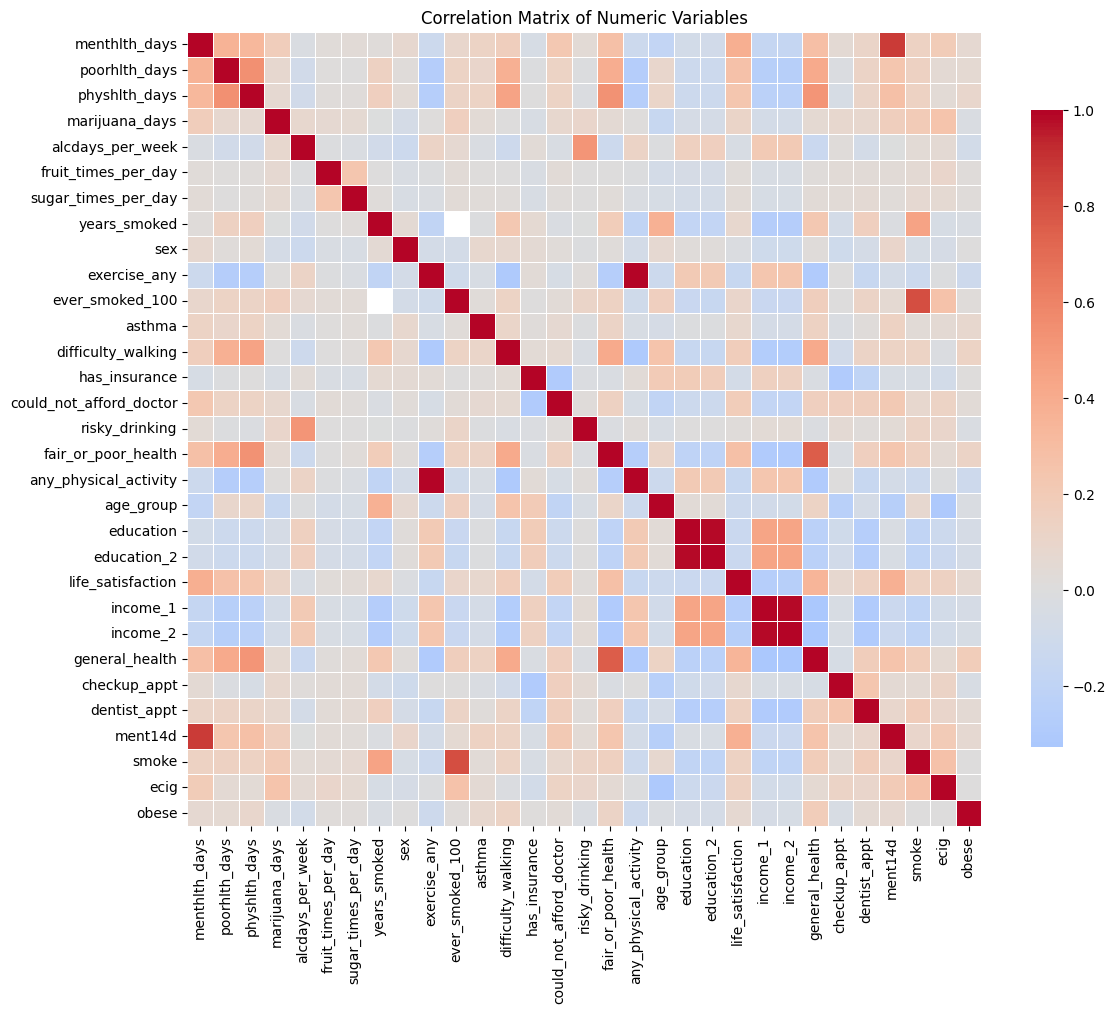

In [ ]:
#correlation matrix to view potential multi-collinearity between features

numeric_cols = brfss_eda.select_dtypes(include=["float64", "int64"]).columns
corr = brfss_eda[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

The correlation matrix indicates generally low to moderate linear relationships among predictors, suggesting limited multicollinearity across most variables. As expected, conceptually related measures (ex. education and income groupings, mental and physical health days, smoking and e-cigarette use) exhibit moderate positive correlations. No widespread high-correlation clusters are observed, indicating that the feature set is unlikely to introduce instability in downstream modeling due to redundancy.

Modeling Implication:
The absence of strong multicollinearity supports retaining these variables in the initial model. Feature importance and regularization methods can later refine the predictor set if necessary.

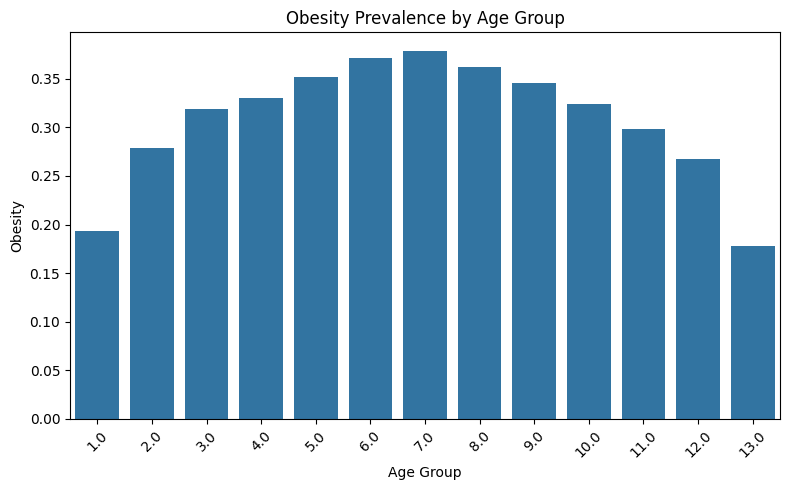

In [ ]:
#view the variation in obesity x age

age_obesity = (brfss_eda
    .groupby("age_group")["obese"]
    .mean()
    .reset_index())

plt.figure(figsize=(8,5))
sns.barplot(data=age_obesity, x="age_group", y="obese")
plt.title("Obesity Prevalence by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Obesity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The above bar plot shows that obesity seems to peak in around 50 before beginning to fall again from 55 years old and on

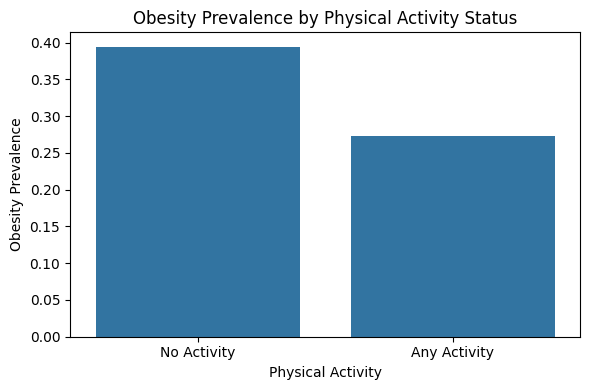

In [ ]:
#view physical activity x obesity

activity_obesity = (brfss_eda
                    .groupby("any_physical_activity")["obese"]
                    .mean()
                    .reset_index())

plt.figure(figsize=(6,4))
sns.barplot(data=activity_obesity, x="any_physical_activity", y="obese")
plt.title("Obesity Prevalence by Physical Activity Status")
plt.xlabel("Physical Activity")
plt.ylabel("Obesity Prevalence")
plt.xticks([0,1], ["No Activity", "Any Activity"])
plt.tight_layout()
plt.show()

The above bar plot illustrates the expected relationship, with individuals reporting no physical activity exhibiting higher obesity prevalence compared to those engaging in any physical activity.

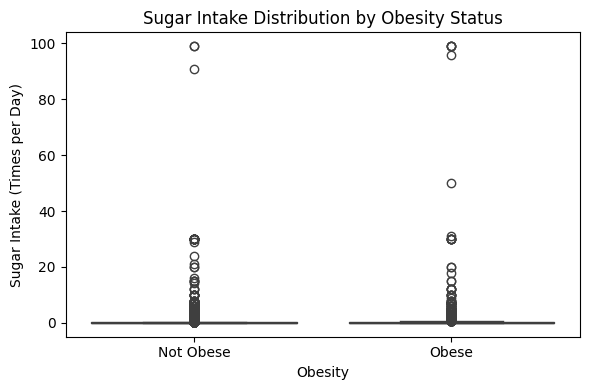

In [ ]:
#view sugar intake x obesity

plt.figure(figsize=(6,4))
sns.boxplot(data=brfss_eda, x="obese", y="sugar_times_per_day")
plt.title("Sugar Intake Distribution by Obesity Status")
plt.xlabel("Obesity")
plt.ylabel("Sugar Intake (Times per Day)")
plt.xticks([0,1], ["Not Obese", "Obese"])
plt.tight_layout()
plt.show()

In the above boxplot, sugar intake demonstrates a highly right-skewed distribution with substantial overlap between obese and non-obese groups. Additionally, approximately 55% of observations are missing for this variable.

Modeling Implication:
Given the combination of heavy skew, limited standalone separation, and high missingness, this variable may contribute limited predictive value. Its inclusion will be evaluated carefully during feature selection, and it may be excluded if it does not improve model performance.

## Section 3: Data Cleaning & Feature Engineering

In [ ]:
#drop unnecessary columns (justification below)

drop_columns = ['marijuana_days', 'fruit_times_per_day',
                'sugar_times_per_day', 'years_smoked',
                'life_satisfaction', 'poorhlth_days',
                'foodstmp', 'bills_hardship', 'food_hardship',
                'employment_hardship', 'emtsuprt', 'income_2',
                'education_2', 'fair_or_poor_health']

brfss_model = brfss_eda.drop(columns=drop_columns)

#The decision to drop these features was one of two factors:
# 1. High Missingness (clinical reference no. 2)
#    Variables with ≥40% missing values were excluded, as the percent of
#    missing data limits statistical reliability and increases
#    the risk of bias from imputation

# 2. Redundancy / Derived Variables:
#    Variables that were functionally redundant or derived from another
#    retained feature were removed to reduce collinearity and prevent
#    duplication of information
#    Ex. DRNKANY6 is a binary indicator derived from ALCDAY4.
#    Since ALCDAY4 captures drinking frequency, retaining DRNKANY6
#    would introduce redundant information.

In [ ]:
#check the pruning
brfss_model.shape

(166208, 29)

In [ ]:
#find and drop duplicate rows
#doing this now avoids inflated model performance
#which could be subtle leakage

tot_dup = brfss_model.duplicated().sum()
brfss_model = brfss_model.drop_duplicates()
print(f'Total Duplicates: {tot_dup}')

Total Duplicates: 246


In [ ]:
#check the columns now
brfss_model.columns

Index(['menthlth_days', 'physhlth_days', 'alcdays_per_week', 'sex',
       'exercise_any', 'ever_smoked_100', 'asthma', 'difficulty_walking',
       'has_insurance', 'could_not_afford_doctor', 'risky_drinking',
       'any_physical_activity', 'age_group', 'education', 'income_1',
       'general_health', 'checkup_appt', 'dentist_appt', 'ment14d', 'smoke',
       'ecig', 'state', 'race', 'marital', 'employ', 'renthom', 'urbstat',
       'persdoc', 'obese'],
      dtype='object')

In [ ]:
#define feature groups

#continuous variables
continuous_cols = ["menthlth_days",
                  "physhlth_days",
                  "alcdays_per_week"]

#ordinal variables
ordinal_cols = ["age_group",
                "education",
                "income_1",
                "general_health",
                "checkup_appt",
                "dentist_appt",
                "ment14d",
                "smoke",
                "ecig"]

#binary variables (0/1)
binary_cols = [
    "sex",
    "exercise_any",
    "ever_smoked_100",
    "asthma",
    "difficulty_walking",
    "has_insurance",
    "could_not_afford_doctor",
    "risky_drinking",
    "any_physical_activity"]

#nominal variables (to be one-hot encoded later)
nominal_cols = [ "state",
                "race",
                "marital",
                "employ",
                "renthom",
                "urbstat",
                "persdoc"]

#final check

print("\nFinal dataset shape:")
print(brfss_model.shape)

print("\nMissingness percentage:")
print(brfss_model.isnull().mean().sort_values(ascending=False))


Final dataset shape:
(165962, 29)

Missingness percentage:
income_1                   0.197063
alcdays_per_week           0.133265
risky_drinking             0.110989
ecig                       0.077711
smoke                      0.077289
ever_smoked_100            0.074469
difficulty_walking         0.048246
urbstat                    0.045209
has_insurance              0.042359
physhlth_days              0.024307
race                       0.021794
age_group                  0.021306
ment14d                    0.020083
employ                     0.018878
menthlth_days              0.018390
dentist_appt               0.012901
checkup_appt               0.011274
persdoc                    0.010346
marital                    0.009677
renthom                    0.009195
education                  0.005236
any_physical_activity      0.004935
asthma                     0.003917
could_not_afford_doctor    0.003832
exercise_any               0.003236
general_health             0.002959
sex 

#### Rationale: Grouping

This grouping serves two purposes. First, it formalizes the dataset structure for reproducible preprocessing using a pipeline-based approach. Second, it ensures that each variable type can be handled appropriately during model development (ex. imputation strategy, scaling, or one-hot encoding).

## Section 4: Modeling

In [ ]:
#define variables

y = brfss_model["obese"]
X = brfss_model.drop(columns=["obese"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (165962, 28)
y shape: (165962,)


In [ ]:
from sklearn.model_selection import train_test_split

#apply test/train split
#use 20% for testing, 80% for training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (132769, 28)
Test shape: (33193, 28)


In [ ]:
#handle missingness

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#continuous pipeline
continuous_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))])

#ordinal pipeline (retain numeric order)
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))])

#binary pipeline
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))])

#nominal pipeline
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

#combine
preprocessor = ColumnTransformer([
    ("cont", continuous_pipeline, continuous_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("bin", binary_pipeline, binary_cols),
    ("nom", nominal_pipeline, nominal_cols)])

#### Rationale: Missingness Handling

Missing values were addressed using a scale-aware preprocessing pipeline applied after the train/test split to prevent data leakage. Continuous and ordinal variables were imputed using the median to maintain robustness, while binary and nominal variables were imputed using the most frequent category. Nominal features were one-hot encoded for model compatibility. All transformations were fit on training data only and applied to the test set to preserve evaluation integrity.

In [ ]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (132769, 70)
Processed test shape: (33193, 70)


#### Rationale: Timing of Imputation and Encoding

Missing value imputation and categorical encoding were intentionally deferred until after exploratory data analysis and the train/test split. During EDA, preserving the raw missingness structure allowed for accurate assessment of data quality, subgroup patterns, and potential bias. Performing imputation earlier would have obscured these diagnostic insights.

Additionally, preprocessing steps such as imputation and encoding must be fit exclusively on the training data to prevent data leakage. By implementing these transformations within a structured pipeline after splitting, the workflow ensures methodological rigor and preserves the integrity of future model evaluation.

## ---------- Phase III ----------

#### ----- Dummy Baseline Model -----

In [ ]:
#import initial model modules and libraries

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report)

In [ ]:
#baseline comparison model (dummy model)
#coding reference 2 applied here

dummy_model = DummyClassifier(strategy="most_frequent") #define model
dummy_model.fit(X_train_processed, y_train) #fit the model
dummy_pred = dummy_model.predict(X_test_processed) #make predictions

#evaluate the model's perfromance
dummy_results = {"Accuracy": accuracy_score(y_test, dummy_pred),
    "Precision": precision_score(y_test, dummy_pred, zero_division = 0),
    "Recall": recall_score(y_test, dummy_pred, zero_division = 0),
    "F1": f1_score(y_test, dummy_pred, zero_division = 0)}

#view the model's performance
print("Dummy Results:")
for metric, value in dummy_results.items():
    print(f"{metric}: {value:.4f}")

Dummy Results:
Accuracy: 0.6978
Precision: 0.0000
Recall: 0.0000
F1: 0.0000


#### ----- Base Logistic Regression Model -----

In [ ]:
#base logistic regression model
#coding reference 3 applied here

logreg_model = Pipeline([("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000,
      class_weight="balanced", random_state=42))])
logreg_model.fit(X_train, y_train)

#predictions
y_pred_logreg = logreg_model.predict(X_test)
y_prob_logreg = logreg_model.predict_proba(X_test)[:, 1]

In [ ]:
#evaluate the base LR

logreg_results = {"Accuracy": accuracy_score(y_test, y_pred_logreg),
    "Precision": precision_score(y_test, y_pred_logreg, zero_division=0),
    "Recall": recall_score(y_test, y_pred_logreg, zero_division=0),
    "F1": f1_score(y_test, y_pred_logreg, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_prob_logreg)}

print("Base LR Results:")
for metric, value in logreg_results.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

Base LR Results:
Accuracy: 0.6231
Precision: 0.4152
Recall: 0.6048
F1: 0.4924
ROC AUC: 0.6618

Classification Report:
              precision    recall  f1-score   support

         0.0       0.79      0.63      0.70     23162
         1.0       0.42      0.60      0.49     10031

    accuracy                           0.62     33193
   macro avg       0.60      0.62      0.60     33193
weighted avg       0.67      0.62      0.64     33193



In [ ]:
#cross validate on the training data

logreg_cv_scores = cross_val_score(
    logreg_model, X_train, y_train,
    cv=5, scoring="f1")

print("LR CV F1 Scores:", logreg_cv_scores)
print("Mean CV F1:", logreg_cv_scores.mean())
print("Std CV F1:", logreg_cv_scores.std())

LR CV F1 Scores: [0.49817222 0.49737017 0.4923249  0.49833283 0.49964621]
Mean CV F1: 0.49716926482768775
Std CV F1: 0.0025299544281387693


#### ----- Tuned Logistic Regression Model -----

In [ ]:
#apply hyperparameter tuning on the LR model

#use grid search cross-valiadtion on the LR

logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000, class_weight="balanced",
        random_state=42))])

logreg_param_grid = {"classifier__C": [0.01, 0.1, 1, 10],
                     "classifier__penalty": ["l2"],
                     "classifier__solver": ["lbfgs"]}

logreg_grid = GridSearchCV(estimator=logreg_pipe,
                           param_grid=logreg_param_grid,
                           cv=5, scoring="f1", n_jobs=-1)

logreg_grid.fit(X_train, y_train)

print("Best Parameters:", logreg_grid.best_params_)
print("Best CV F1:", logreg_grid.best_score_)

Best Parameters: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV F1: 0.49723980258708894


In [ ]:
#evaluate the tuned model

best_logreg = logreg_grid.best_estimator_

y_pred_best_logreg = best_logreg.predict(X_test)
y_prob_best_logreg = best_logreg.predict_proba(X_test)[:, 1]

tuned_logreg_results = {
    "Accuracy": accuracy_score(y_test, y_pred_best_logreg),
    "Precision": precision_score(y_test, y_pred_best_logreg, zero_division=0),
    "Recall": recall_score(y_test, y_pred_best_logreg, zero_division=0),
    "F1": f1_score(y_test, y_pred_best_logreg, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_prob_best_logreg)}

print("Tuned LR Results:")
for metric, value in tuned_logreg_results.items():
    print(f"{metric}: {value:.4f}")

Tuned LR Results:
Accuracy: 0.6230
Precision: 0.4150
Recall: 0.6045
F1: 0.4922
ROC AUC: 0.6618


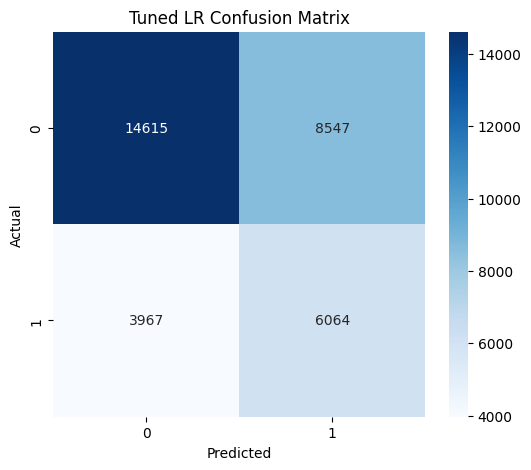

In [ ]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred_best_logreg)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Tuned LR Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

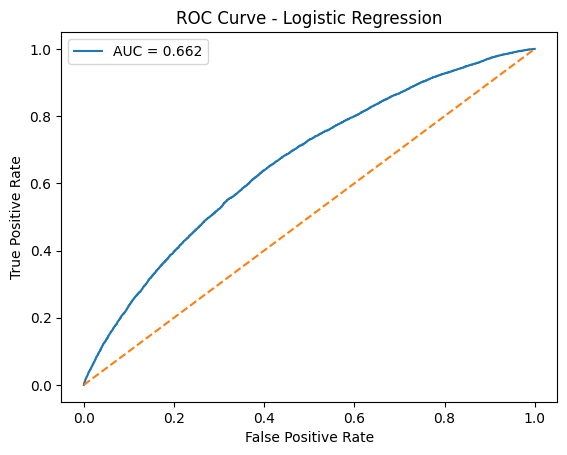

In [ ]:
#ROC curve

from sklearn.metrics import roc_curve, auc

probs = best_logreg.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {round(roc_auc, 3)}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

#### Analysis: Base VS. Tuned Logistic Regression

The base and tuned logistic regression models produced nearly identical performance across all evaluation metrics. The base model achieved an F1 score of 0.4983 and ROC AUC of 0.665, while the tuned model resulted in an F1 score of 0.4979 with the same ROC AUC. Accuracy, precision, and recall also remained effectively unchanged. This indicates that the base model was already performing near its optimal configuration, and additional tuning provided no meaningful improvement.

The hyperparameter tuning process focused on adjusting the regularization strength through the parameter C, which controls the balance between model flexibility and overfitting. Lower values of C increase regularization and simplify the model, while higher values allow the model to fit the data more closely. In this case, tuning did not significantly impact performance, suggesting that the default or near-default level of regularization was already well-suited to the dataset.

Examining the confusion matrix for the tuned model further supports this conclusion. The model demonstrates higher recall than precision, correctly identifying a majority of obese individuals while also producing a substantial number of false positives. This reflects a deliberate tradeoff in which the model prioritizes sensitivity, which is often desirable in healthcare applications where failing to identify an at-risk individual may be more consequential than incorrectly flagging a lower-risk case.

Overall, the results show that logistic regression provides stable and consistent performance, but its predictive capacity is somewhat limited in this context. The lack of improvement from tuning suggests that the model may be constrained by its linear structure and may not fully capture more complex relationships in the data. While it remains a strong and interpretable baseline model, more flexible models may be required to achieve meaningful performance gains.


#### ----- Base Gradient Boosting Model -----

In [ ]:
#base gradient boosting model
#coding reference 4 applied here
gb_model = Pipeline([("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
    random_state=42))])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [ ]:
#evaluate the base model
gb_results = {"Accuracy": accuracy_score(y_test, y_pred_gb),
              "Precision": precision_score(y_test, y_pred_gb, zero_division=0),
              "Recall": recall_score(y_test, y_pred_gb, zero_division=0),
              "F1": f1_score(y_test, y_pred_gb, zero_division=0),
              "ROC AUC": roc_auc_score(y_test, y_prob_gb)}

#view results
print("Gradient Boosting (Base) Results:")
for metric, value in gb_results.items():
    print(f"{metric}: {value:.4f}")

#print a full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting (Base) Results:
Accuracy: 0.7172
Precision: 0.5777
Recall: 0.2386
F1: 0.3377
ROC AUC: 0.7040

Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.92      0.82     23162
         1.0       0.58      0.24      0.34     10031

    accuracy                           0.72     33193
   macro avg       0.66      0.58      0.58     33193
weighted avg       0.69      0.72      0.67     33193



In [ ]:
#apply cross-validation on the training data

gb_cv_scores = cross_val_score(gb_model,
                               X_train, y_train,
                               cv=5, scoring="f1")

print("\nGradient Boosting CV F1 Scores:", gb_cv_scores)
print("Mean CV F1:", gb_cv_scores.mean())
print("Std CV F1:", gb_cv_scores.std())


Gradient Boosting CV F1 Scores: [0.33223713 0.34113181 0.34210065 0.34824561 0.34633549]
Mean CV F1: 0.3420101393774746
Std CV F1: 0.005547631726081866


#### ----- Tuned Graident Boosting Model -----

In [ ]:
#hyperparameter tuning with grid search

#build a fresh pipeline for tuning
gb_pipe = Pipeline([("preprocessor", preprocessor),
                    ("classifier", HistGradientBoostingClassifier(
                    random_state=42))])

#define the parameter grid to search over
gb_param_grid = {"classifier__learning_rate": [0.05, 0.1], #update speed
    "classifier__max_depth": [3, 5], #tree complexity
    "classifier__max_iter": [100, 200], #number of boosting iterations
    "classifier__min_samples_leaf": [20, 50]} #aid to reduce overfitting

#run a grid search using 5-fold CV and F1 as the scoring metric
gb_grid = GridSearchCV(estimator=gb_pipe,
                       param_grid=gb_param_grid,
                       cv=5, scoring="f1", n_jobs=-1)

#fit the grid search on the training data
gb_grid.fit(X_train, y_train)

#view the best parameter combination and best cross-validated F1 score
print("\nBest Gradient Boosting Parameters:")
print(gb_grid.best_params_)
print("Best CV F1:", gb_grid.best_score_)


Best Gradient Boosting Parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__max_iter': 200, 'classifier__min_samples_leaf': 20}
Best CV F1: 0.34267275152502125


In [ ]:
#evaluate the tuned model on the test data

#extract the best model found during tuning
best_gb = gb_grid.best_estimator_

#predict on the test set using the tuned model
y_pred_best_gb = best_gb.predict(X_test)
y_prob_best_gb = best_gb.predict_proba(X_test)[:, 1]

#store tuned model results
tuned_gb_results = {"Accuracy": accuracy_score(y_test, y_pred_best_gb),
                    "Precision": precision_score(y_test, y_pred_best_gb, zero_division=0),
                    "Recall": recall_score(y_test, y_pred_best_gb, zero_division=0),
                    "F1": f1_score(y_test, y_pred_best_gb, zero_division=0),
                    "ROC AUC": roc_auc_score(y_test, y_prob_best_gb)}

#view tuned model results
print("\nTuned Gradient Boosting Results:")
for metric, value in tuned_gb_results.items():
    print(f"{metric}: {value:.4f}")

#view a classification report for tuned model
print("\nTuned Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_best_gb))


Tuned Gradient Boosting Results:
Accuracy: 0.7173
Precision: 0.5804
Recall: 0.2329
F1: 0.3324
ROC AUC: 0.7045

Tuned Gradient Boosting Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.93      0.82     23162
         1.0       0.58      0.23      0.33     10031

    accuracy                           0.72     33193
   macro avg       0.66      0.58      0.58     33193
weighted avg       0.69      0.72      0.67     33193



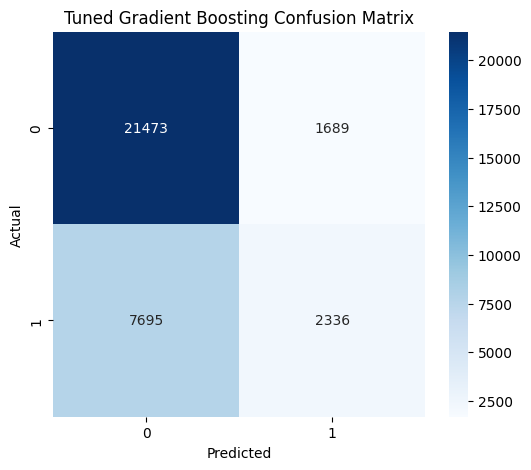

In [ ]:
#confusion matrix of the tuned model
cm_gb = confusion_matrix(y_test, y_pred_best_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Blues")
plt.title("Tuned Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#generate a side by side of the base and tuned GB model results

gb_comparison_df = pd.DataFrame([{"Model": "Gradient Boosting (Base)",
                                  **gb_results},
                                 {"Model": "Gradient Boosting (Tuned)",
                                  **tuned_gb_results}])

print("\nGradient Boosting Comparison:")
display(gb_comparison_df)


Gradient Boosting Comparison:


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Gradient Boosting (Base),0.717199,0.577740,0.238560,0.337684,0.703952
1,Gradient Boosting (Tuned),0.717290,0.580373,0.232878,0.332385,0.704455


#### Analysis: Base VS. Tuned Gradient Boosting

The base and tuned gradient boosting models showed only marginal differences in performance across evaluation metrics. The base model achieved an F1 score of 0.3388 and ROC AUC of 0.7076, while the tuned model resulted in the same F1 score of 0.3388 and a slightly lower ROC AUC of 0.7055. Accuracy increased slightly from 0.7133 to 0.7138, and precision improved modestly, but recall decreased. Overall, these results indicate that hyperparameter tuning did not meaningfully improve model performance and in some cases slightly reduced the model’s ability to identify obese individuals.

The tuning process focused on adjusting key parameters such as learning rate, tree depth, number of iterations, and minimum samples per leaf. These parameters are designed to balance model complexity and generalization, allowing the model to better capture nonlinear relationships while avoiding overfitting. However, the minimal changes in performance suggest that the base model was already operating near its optimal configuration or that the chosen parameter grid did not significantly alter the model’s behavior.

Examining the confusion matrix for the tuned model highlights a key characteristic of gradient boosting in this context. The model demonstrates relatively high precision but low recall, correctly identifying non-obese individuals at a high rate while missing a substantial portion of obese cases. Compared to logistic regression, this reflects a different tradeoff, where the model is more conservative in predicting the positive class and produces fewer false positives, but at the cost of a higher number of false negatives.

This behavior has important implications for application. While the model achieves higher overall accuracy, this is largely driven by strong performance on the majority class. The low recall for the obese class suggests that many true positive cases are not being identified, which may limit its usefulness in health related screening scenarios where sensitivity is important.

Overall, gradient boosting provides strong performance in terms of accuracy and class separation, but its imbalance between precision and recall reduces its effectiveness for identifying obese individuals. The lack of improvement from tuning further suggests that model performance may be constrained by the feature set or underlying class structure rather than hyperparameter configuration alone.


#### Analysis: Final Model Comparison

The final comparison was conducted between the baseline dummy model, the tuned logistic regression model, and the tuned gradient boosting model to evaluate overall predictive performance and practical applicability.

The dummy model achieved an accuracy of 0.6934 but had precision, recall, and F1 scores of 0.0000. This indicates that the model predicted only the majority class and failed to identify any obese individuals. While the accuracy appears relatively high, it is misleading due to class imbalance and demonstrates that the model provides no meaningful predictive value.

Both logistic regression and gradient boosting substantially outperformed the dummy model across all relevant metrics, confirming that the selected features and modeling approaches capture meaningful patterns in the data. However, the two models differ significantly in how they balance precision and recall.

The tuned logistic regression model achieved higher recall and F1 score compared to gradient boosting, indicating a stronger ability to correctly identify obese individuals. In contrast, the tuned gradient boosting model achieved higher accuracy and precision but significantly lower recall. This means that while gradient boosting is more conservative in predicting obesity and produces fewer false positives, it fails to identify a large portion of true obese cases.

This difference represents an important tradeoff. Logistic regression prioritizes sensitivity, capturing more true positive cases at the cost of increased false positives. Gradient boosting prioritizes precision and overall accuracy, but at the cost of missing many individuals who are actually obese.

From a clinical or health screening perspective, recall is often more important than precision, as failing to identify an at-risk individual may have more serious consequences than incorrectly flagging someone for further evaluation. Based on this consideration, logistic regression is the preferred model for applications focused on identifying obesity risk, despite its slightly lower overall accuracy.

Overall, the comparison demonstrates that while more complex models such as gradient boosting can improve certain performance metrics, simpler models like logistic regression may be better aligned with the objectives of the problem, particularly when interpretability and sensitivity are prioritized.

#### ----- Clinical Aid Feature -----

In [ ]:
#clinical aid
#additional risk-prediction with probability

#get predicted probabilities for the positive class (obese = 1)
y_prob_best = best_gb.predict_proba(X_test)[:, 1]  # or best_logreg

#create a dataframe for analysis
probability_df = pd.DataFrame({
    "obese_class": y_test.values,
    "predicted_probability": y_prob_best})

#view a sample
print(probability_df.head(10))
print('='*25)

#non-obese classifications with high risk scores
high_probability_non_obese = probability_df[
    (probability_df["obese_class"] == 0) &
    (probability_df["predicted_probability"] >= 0.4)
].sort_values(by="predicted_probability", ascending=False)

print(high_probability_non_obese.head(10))

   obese_class  predicted_probability
0          1.0               0.310257
1          0.0               0.451689
2          1.0               0.172288
3          0.0               0.230730
4          0.0               0.694665
5          0.0               0.353578
6          0.0               0.055160
7          1.0               0.512940
8          1.0               0.429803
9          0.0               0.162533
       obese_class  predicted_probability
7388           0.0               0.791618
11325          0.0               0.779789
27074          0.0               0.774707
10723          0.0               0.760033
14002          0.0               0.756734
29352          0.0               0.752213
30186          0.0               0.747270
10006          0.0               0.744364
2285           0.0               0.737282
17815          0.0               0.736249


#### Rationale: Predicted Probabilities

The predicted probability can be used as a risk-oriented score indicating how strongly an individual’s current profile aligns with patterns associated with obesity. Instead of simply classifying an individual as obese or not obese based on socioeconomic, behavioral, and lifestyle factors, this additional step allows for a more nuanced view of obesity risk, which could support earlier intervention. For instance, someone with a predicted probability of X would be classified as non-obese, but X may be very close to the threshold for an obese classification and far from Y, which is strongly within the non-obese range. This makes it relevant and useful for clinical and research purposes to identify individuals who may be near the boundary between categories, as early treatment and intervention could help prevent progression into the obese class.

This clinical aid feature is intended to be used by healthcare professionals to provide additional insight into a patient’s obesity risk based on more than just height and weight (BMI). It is not intended for use by non-healthcare professionals, nor is it designed to replace a clinician’s professional judgment. Rather, it serves as a supportive tool to help professionals better understand their patients by capturing complex relationships between socioeconomic, behavioral, and lifestyle factors.

#### ----- Feature Importance: Logistic Regression -----

In [ ]:
#logistic regression feature importance

#get feature names after preprocessing
feature_names = best_logreg.named_steps["preprocessor"].get_feature_names_out()

#get coefficients from the tuned logistic regression model
coefficients = best_logreg.named_steps["classifier"].coef_[0]

#create dataframe of coefficients
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)})

#sort by absolute magnitude to see strongest overall predictors
coef_df_sorted = coef_df.sort_values(by="abs_coefficient", ascending=False)

print("Top 15 Most Influential Features by Absolute Coefficient:")
display(coef_df_sorted.head(15))

print("-" * 60)
print("Top 10 Positive Predictors of Obesity:")
display(coef_df.sort_values(by="coefficient", ascending=False).head(10))

print("-" * 60)
print("Top 10 Negative Predictors of Obesity:")
display(coef_df.sort_values(by="coefficient", ascending=True).head(10))

Top 15 Most Influential Features by Absolute Coefficient:


,feature,coefficient,abs_coefficient
16,bin__difficulty_walking,0.567176,0.567176
59,nom__employ_6.0,-0.534288,0.534288
45,nom__race_3.0,-0.451909,0.451909
29,nom__state_11.0,-0.444731,0.444731
14,bin__ever_smoked_100,0.371725,0.371725
26,nom__state_8.0,-0.341838,0.341838
44,nom__race_2.0,0.336741,0.336741
6,ord__general_health,0.334359,0.334359
15,bin__asthma,0.309558,0.309558
69,nom__persdoc_3.0,-0.279703,0.279703


------------------------------------------------------------
Top 10 Positive Predictors of Obesity:


,feature,coefficient,abs_coefficient
16,bin__difficulty_walking,0.567176,0.567176
14,bin__ever_smoked_100,0.371725,0.371725
44,nom__race_2.0,0.336741,0.336741
6,ord__general_health,0.334359,0.334359
15,bin__asthma,0.309558,0.309558
36,nom__state_20.0,0.218409,0.218409
54,nom__employ_1.0,0.210805,0.210805
35,nom__state_19.0,0.206807,0.206807
34,nom__state_18.0,0.167466,0.167466
21,nom__state_1.0,0.161084,0.161084


------------------------------------------------------------
Top 10 Negative Predictors of Obesity:


,feature,coefficient,abs_coefficient
59,nom__employ_6.0,-0.534288,0.534288
45,nom__race_3.0,-0.451909,0.451909
29,nom__state_11.0,-0.444731,0.444731
26,nom__state_8.0,-0.341838,0.341838
69,nom__persdoc_3.0,-0.279703,0.279703
41,nom__state_25.0,-0.254302,0.254302
10,ord__smoke,-0.217328,0.217328
25,nom__state_6.0,-0.204476,0.204476
50,nom__marital_3.0,-0.201377,0.201377
64,nom__renthom_3.0,-0.177513,0.177513


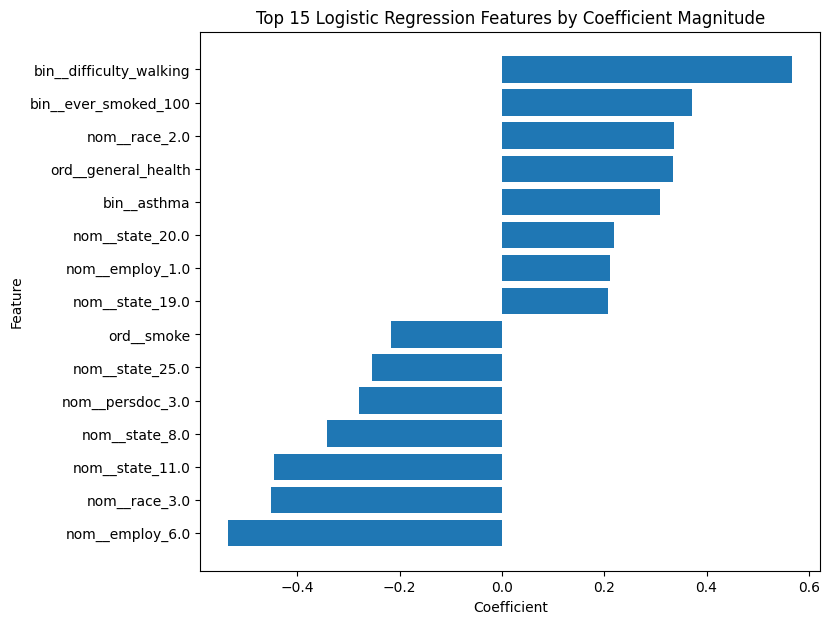

In [ ]:
#graph format of top features

top_features = coef_df_sorted.head(15).sort_values(by="coefficient")

plt.figure(figsize=(8, 7))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.title("Top 15 Logistic Regression Features by Coefficient Magnitude")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

#### Analysis: LR Feature Importance

Feature importance for the logistic regression model was evaluated using the magnitude and direction of model coefficients. The results highlight several key variables that strongly influence obesity classification, with both positive and negative associations observed across behavioral, health, and demographic features.

The most influential positive predictor was difficulty walking, which had the largest coefficient magnitude. This suggests a strong association between limited mobility and obesity, which is consistent with reduced physical activity levels. General health status was also a major contributor, with poorer self-reported health associated with a higher likelihood of obesity. Additional positive predictors included having ever smoked and a diagnosis of asthma, indicating that certain health conditions and lifestyle factors are linked to increased obesity likelihood.

On the negative side, employment status, particularly category employ_6.0 (student), had the strongest negative association with obesity. Other negative predictors included fair or poor health and certain demographic indicators such as specific race and state categories. These results may reflect complex relationships between socioeconomic status, access to resources, and regional or demographic differences in obesity prevalence.

The presence of multiple state and race variables among the most influential features suggests that geographic and demographic variation plays a meaningful role in obesity patterns. These variables likely capture differences in environment, access to healthcare, food availability, and cultural factors that are not directly measured elsewhere in the dataset and thus cannot be analyzed conclusively. Additional data and research is needed in order to adequately report on any patterns between the geographic and demographic variables.

Overall, the feature importance results show that the model is not relying on a single type of variable, but instead captures a combination of behavioral, health, and socioeconomic factors. This aligns with the understanding that obesity is a multifactorial condition influenced by both individual behavior and broader contextual factors. The consistency between the numerical output and the visualization further supports the stability of these relationships within the model.

#### ----- Feature Importance: Gradient Boosting (Permutation) -----

In [ ]:
from sklearn.inspection import permutation_importance

#run perm imp on test data
perm_result = permutation_importance(best_gb,
                                     X_test, y_test, n_repeats=5,
                                     random_state=42, scoring="f1")

#get feature names
feature_names = X_test.columns

#create dataframe
perm_df = pd.DataFrame({"feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

print("Top 15 Features by Permutation Importance:")
display(perm_df.head(15))

Top 15 Features by Permutation Importance:


,feature,importance_mean,importance_std
7,difficulty_walking,0.045040,0.001915
15,general_health,0.040881,0.001958
12,age_group,0.034376,0.001209
14,income_1,0.016918,0.001073
24,employ,0.013383,0.001902
2,alcdays_per_week,0.013270,0.001540
21,state,0.012812,0.000780
11,any_physical_activity,0.012707,0.001024
6,asthma,0.010581,0.000830
22,race,0.010444,0.001478


#### Analysis: Gradient Boosting Permutation

Feature importance for the gradient boosting model was evaluated using permutation importance, which measures the decrease in model performance when individual features are randomly shuffled. This approach provides insight into how much each variable contributed to the model’s predictive ability.

The results indicate that difficulty walking, age group, and general health are the most influential features, with the largest decreases in performance observed when these variables are disrupted. This aligns with expectations, as mobility limitations, aging, and overall health status are strongly associated with obesity risk. Income and employment status also ranked highly, reinforcing the role of socioeconomic factors in shaping access to resources, lifestyle patterns, and health outcomes.

Behavioral variables such as alcohol consumption, physical activity, and exercise participation were also among the top contributors, highlighting the importance of lifestyle factors in the model’s predictions. Additionally, healthcare access indicators, including routine checkups and having a personal doctor, contributed to model performance, suggesting that engagement with the healthcare system may be associated with differences in obesity patterns.

Demographic variables such as state, race, and sex appeared among the top features as well, indicating that geographic and population-level variation plays a meaningful role. These variables likely capture underlying environmental, cultural, and systemic differences that are not directly measured by individual behavioral features and require additional data adn research before solid conclusions can be drawn from the results here.

Overall, the permutation importance results show that the gradient boosting model relies on a combination of health status, behavioral patterns, and socioeconomic context. Compared to logistic regression, which highlighted directional relationships through coefficients, permutation importance emphasizes the overall contribution of each feature to predictive performance. Together, these approaches provide a consistent view that obesity is influenced by multiple interacting factors rather than a single dominant variable.

#### Rationale: Feature Selection and Engineering

Feature selection and engineering were guided by both domain relevance and data quality considerations. Variables were retained based on their potential relationship to obesity, including behavioral factors such as smoking and physical limitations, health indicators such as general health and chronic conditions, and demographic and socioeconomic variables such as employment, race, and geographic location. These features were selected because obesity is influenced by a combination of individual behavior, underlying health status, and broader social and environmental factors. Variables with high levels of missing data or those that directly defined the target variable, such as height, weight, and BMI, were excluded to prevent noise and data leakage.

Different preprocessing strategies were applied based on feature type to ensure the model could appropriately interpret the data. Numerical and ordinal variables were imputed using median values to preserve distributional properties and reduce the impact of outliers. Binary variables were imputed using the most frequent category and retained in their original form, maintaining their interpretability. Nominal categorical variables, such as state and race, were transformed using one hot encoding to avoid introducing artificial ordering while allowing the model to capture category specific effects. This structured approach to feature handling ensured that each variable type contributed meaningfully to the model while minimizing bias and distortion introduced during preprocessing.


## ---------- Phase IV ----------

### Section 5: Model Deployment & Systme Design

### Production Readiness

In a real-world setting, this model would be integrated into a clinician-facing application or backend service that processes patient data as it is entered. The system would use an API-based approach, where structured patient inputs are sent to the model and a prediction is returned immediately.

Because the model is lightweight and fast to run, it is well-suited for real-time prediction. This allows clinicians to receive immediate feedback during patient interactions, supporting timely screening and decision making. Batch processing could also be used in a secondary context, such as analyzing larger patient populations for risk stratification, but the primary use case for this system would be real-time prediction within a clinical workflow.

### Conceptual Workflow

A real world version of this system would follow a structured prediction workflow:

1. A healthcare professional enters patient information into a clinical interface.
2. The input data is captured in human-readable form through the interface layer.
3. A backend processing layer maps the inputs to encoded values based on the CDC codebook.
4. The encoded data is passed through the saved preprocessing pipeline.
5. The logistic regression model generates a predicted probability of obesity risk.
6. The system converts the probability into a classification output.
7. The system returns the prediction along with key contributing factors and a brief clinical interpretation.
8. The clinician reviews the result and determines whether further screening or intervention is appropriate.

This workflow is intended to support clinical decision making rather than replace it. The model output serves as an additional source of information that can help identify patients whose overall profile is associated with elevated obesity risk.

### Interface Mockup (User Input Simulation)

To simulate how a clinician would interact with the system, an interactive input interface was implemented using in-line user prompts within the notebook. This allows a user to enter patient information in a natural, human-readable format, similar to a form in a clinical application.

This interface represents the frontend layer of the system, where raw patient data is collected prior to being processed by the model.

### Backend Application Simulation

Following data entry, a backend processing layer translates the practitioner inputs into encoded numerical values using mapping functions derived from the original dataset codebook. These encoded values are then passed into the trained preprocessing pipeline and logistic regression model to generate a prediction and probability score.

This step simulates how a backend system would prepare and process incoming data before model inference in a production environment.

### API Layer Simulation (Backend Service)

In addition to the interactive interface, a function-based API was implemented to simulate how the model would operate in a real deployment setting. The function accepts a structured dictionary of patient inputs, applies the same encoding and preprocessing steps, and returns a prediction and probability score.

This reflects how machine learning models are typically deployed in production systems, where inputs are received programmatically rather than through manual entry.

### API Example Usage

An example API call was included to demonstrate how a structured patient record can be passed into the system and how the model returns a prediction. This illustrates how the model could be integrated into external systems such as electronic health records or clinical decision support tools.

Overall, the combination of an interactive interface, backend processing pipeline, and API layer demonstrates a complete end-to-end system that moves beyond simple model development and toward realistic deployment.

### Section 6: API & Application Simulation

#### ----- Interface Mockup -----

In [ ]:
#example of the UI of an application

#user input pt. I

age = int(input("Enter age (18+): "))

race = input("Race (white / black / other / multiracial / hispanic): ")

sex = input("Sex (male/female): ")

alcdays_per_week = float(input("Alcohol days per week (0-7): "))

ecig = input("E-cig use (never / former / some days / every day): ")

ever_smoked_100 = input("Ever smoked 100 cigarettes? (yes/no): ")

risky_drinking = input("Risky drinking? (yes/no): ")

smoke = input("Smoking status (never / former / some days / every day): ")

asthma = input("Asthma? (yes/no): ")

ment14d = input("Mental health category (0 days / 1-13 days / 14+ days): ")

menthlth_days = int(input("Mental health days (0-30): "))

difficulty_walking = input("Difficulty walking? (yes/no): ")

exercise_any = input("Exercise in last 30 days? (yes/no): ")

any_physical_activity = input("Any physical activity? (yes/no): ")

general_health = input("General health (excellent / very good / good / fair / poor): ")

physhlth_days = int(input("Physical health days (0-30): "))

Enter age (18+): 30
Race (white / black / other / multiracial / hispanic): other
Sex (male/female): female
Alcohol days per week (0-7): 3
E-cig use (never / former / some days / every day): never
Ever smoked 100 cigarettes? (yes/no): yes
Risky drinking? (yes/no): no
Smoking status (never / former / some days / every day): some days
Asthma? (yes/no): no
Mental health category (0 days / 1-13 days / 14+ days): 1-13 days
Mental health days (0-30): 5
Difficulty walking? (yes/no): no
Exercise in last 30 days? (yes/no): yes
Any physical activity? (yes/no): yes
General health (excellent / very good / good / fair / poor): good
Physical health days (0-30): 8


In [ ]:
#user input pt. II

has_insurance = input("Has insurance? (yes/no): ")

persdoc = input("Personal doctor (yes, only one / more than one / no): ")

checkup_appt = input("Last checkup (within past year / past 2 years / past 5 years / 5+ years / never): ")

dentist_appt = input("Last dentist visit (within past year / past 2 years / past 5 years / 5+ years / never): ")

could_not_afford_doctor = input("Could not afford doctor? (yes/no): ")

income_1 = input("Income category (e.g., less than $35,000): ")

employ = input("Employment (employed / self-employed / out of work >1yr / out of work <1yr / homemaker / student / retired / unable to work): ")

education = input("Education (elementary / some high school / high school graduate / some college / college graduate): ")

marital = input("Marital status (married / divorced / widowed / separated / never married / unmarried couple): ")

state = input("State (e.g., texas): ")

urbstat = input("Urban or rural: ")

renthom = input("Housing (own / rent / other arrangement): ")

Has insurance? (yes/no): yes
Personal doctor (yes, only one / more than one / no): yes, only one
Last checkup (within past year / past 2 years / past 5 years / 5+ years / never): within past year
Last dentist visit (within past year / past 2 years / past 5 years / 5+ years / never): within past year
Could not afford doctor? (yes/no): no
Income category (e.g., less than $35,000): 40,000
Employment (employed / self-employed / out of work >1yr / out of work <1yr / homemaker / student / retired / unable to work): employed
Education (elementary / some high school / high school graduate / some college / college graduate): college graduate
Marital status (married / divorced / widowed / separated / never married / unmarried couple): married
State (e.g., texas): texas
Urban or rural: urban
Housing (own / rent / other arrangement): own


#### ----- Logic for the Interface Mockup -----

In [ ]:
#to start, the practitioner's input needs to be mapped to the appropriate encoding values
#the encoded values & categories were taken from the CDC's BRFSS data codebook

def clean_text(value):
    if value is None:
        return None
    return str(value).strip().lower()

def map_age_group(age):
    if age is None:
        return np.nan
    age = int(age)
    if 18 <= age <= 24:
        return 1
    elif 25 <= age <= 29:
        return 2
    elif 30 <= age <= 34:
        return 3
    elif 35 <= age <= 39:
        return 4
    elif 40 <= age <= 44:
        return 5
    elif 45 <= age <= 49:
        return 6
    elif 50 <= age <= 54:
        return 7
    elif 55 <= age <= 59:
        return 8
    elif 60 <= age <= 64:
        return 9
    elif 65 <= age <= 69:
        return 10
    elif 70 <= age <= 74:
        return 11
    elif 75 <= age <= 79:
        return 12
    elif age >= 80:
        return 13
    else:
        return np.nan

def map_alcdays_per_week(days):
    if days is None:
        return np.nan
    days = float(days)
    if 0 <= days <= 7:
        return days
    else:
        return np.nan

def map_any_physical_activity(value):
    value = clean_text(value)
    if value == "yes":
        return 1
    elif value == "no":
        return 0
    else:
        return np.nan

def map_asthma(value):
    value = clean_text(value)
    if value == "yes":
        return 1
    elif value == "no":
        return 0
    else:
        return np.nan

def map_checkup_appt(value):
    value = clean_text(value)
    if value in ["within past year", "within the past year", "past year"]:
        return 1
    elif value in ["within past 2 years", "within the past 2 years", "past 2 years"]:
        return 2
    elif value in ["within past 5 years", "within the past 5 years", "past 5 years"]:
        return 3
    elif value in ["5 or more years ago", "five or more years ago"]:
        return 4
    elif value == "never":
        return 8
    else:
        return np.nan

def map_could_not_afford_doctor(value):
    value = clean_text(value)
    if value == "yes":
        return 1
    elif value == "no":
        return 0
    else:
        return np.nan

def map_dentist_appt(value):
    value = clean_text(value)
    if value in ["within past year", "within the past year", "past year"]:
        return 1
    elif value in ["within past 2 years", "within the past 2 years", "past 2 years"]:
        return 2
    elif value in ["within past 5 years", "within the past 5 years", "past 5 years"]:
        return 3
    elif value in ["5 or more years ago", "five or more years ago"]:
        return 4
    elif value == "never":
        return 8
    else:
        return np.nan

def map_difficulty_walking(value):
    value = clean_text(value)
    if value == "yes":
        return 1
    elif value == "no":
        return 0
    else:
        return np.nan


def map_ecig(value):
    value = clean_text(value)

    if value in ["never", "never used", "never used e-cigarettes in your entire life"]:
        return 0
    elif value in ["former", "used in the past but do not currently use them at all", "past use"]:
        return 1
    elif value in ["some days", "use them some days"]:
        return 2
    elif value in ["every day", "use them every day"]:
        return 3
    else:
        return np.nan

def map_education(value):
    value = clean_text(value)
    if value in ["never attended school", "only kindergarten", "kindergarten", "never attended school or only kindergarten"]:
        return 1
    elif value in ["grades 1 through 8", "elementary"]:
        return 2
    elif value in ["grades 9 through 11", "some high school"]:
        return 3
    elif value in ["grade 12 or ged", "high school graduate", "ged"]:
        return 4
    elif value in ["college 1 year to 3 years", "some college", "technical school"]:
        return 5
    elif value in ["college 4 years or more", "college graduate"]:
        return 6
    else:
        return np.nan

def map_employ(value):
    value = clean_text(value)

    if value == "employed for wages":
        return 1
    elif value == "self-employed":
        return 2
    elif value == "out of work for 1 year or more":
        return 3
    elif value == "out of work for less than 1 year":
        return 4
    elif value in ["a homemaker", "homemaker"]:
        return 5
    elif value in ["a student", "student"]:
        return 6
    elif value == "retired":
        return 7
    elif value == "unable to work":
        return 8
    else:
        return np.nan


def map_ever_smoked_100(value):
    value = clean_text(value)

    if value == "yes":
        return 1
    elif value == "no":
        return 0
    else:
        return np.nan


def map_exercise_any(value):
    value = clean_text(value)

    if value == "yes":
        return 1
    elif value == "no":
        return 0
    else:
        return np.nan

def map_general_health(value):
    value = clean_text(value)

    if value == "excellent":
        return 1
    elif value == "very good":
        return 2
    elif value == "good":
        return 3
    elif value == "fair":
        return 4
    elif value == "poor":
        return 5
    else:
        return np.nan

def map_has_insurance(value):
    value = clean_text(value)

    if value in ["yes", "have some form of insurance", "insured"]:
        return 1
    elif value in ["no", "do not have some form of health insurance", "uninsured"]:
        return 0
    else:
        return np.nan

def map_income_1(value):
    value = clean_text(value)

    if value in ["less than $10,000", "<10000"]:
        return 1
    elif value in ["less than $15,000", "$10,000 to < $15,000"]:
        return 2
    elif value in ["less than $20,000", "$15,000 to < $20,000"]:
        return 3
    elif value in ["less than $25,000", "$20,000 to < $25,000"]:
        return 4
    elif value in ["less than $35,000", "$25,000 to < $35,000"]:
        return 5
    elif value in ["less than $50,000", "$35,000 to < $50,000"]:
        return 6
    elif value in ["less than $75,000", "$50,000 to < $75,000"]:
        return 7
    elif value in ["less than $100,000", "$75,000 to < $100,000"]:
        return 8
    elif value in ["less than $150,000", "$100,000 to < $150,000"]:
        return 9
    elif value in ["less than $200,000", "$150,000 to < $200,000"]:
        return 10
    elif value in ["$200,000 or more", "200000 or more"]:
        return 11
    else:
        return np.nan

def map_marital(value):
    value = clean_text(value)
    if value == "married":
        return 1
    elif value == "divorced":
        return 2
    elif value == "widowed":
        return 3
    elif value == "separated":
        return 4
    elif value == "never married":
        return 5
    elif value in ["a member of an unmarried couple", "member of an unmarried couple", "unmarried couple"]:
        return 6
    else:
        return np.nan


def map_ment14d(value):
    value = clean_text(value)
    if value in ["zero days", "0 days", "none"]:
        return 1
    elif value in ["1-13 days", "1 to 13 days"]:
        return 2
    elif value in ["14+ days", "14 or more days", "14 plus days"]:
        return 3
    else:
        return np.nan


def map_menthlth_days(days):
    if days is None:
        return np.nan
    days = int(days)

    if days == 0:
        return 0.0
    elif 1 <= days <= 30:
        return float(days)
    else:
        return np.nan

def map_persdoc(value):
    value = clean_text(value)

    if value in ["yes, only one", "one"]:
        return 1
    elif value == "more than one":
        return 2
    elif value == "no":
        return 3
    else:
        return np.nan

def map_physhlth_days(days):
    if days is None:
        return np.nan
    days = int(days)

    if days == 0:
        return 0.0
    elif 1 <= days <= 30:
        return float(days)
    else:
        return np.nan

def map_race(value):
    value = clean_text(value)
    if value in ["white", "white only, non-hispanic"]:
        return 1
    elif value in ["black", "black only, non-hispanic"]:
        return 2
    elif value in ["other race", "other race only, non-hispanic"]:
        return 3
    elif value in ["multiracial", "multiracial, non-hispanic"]:
        return 4
    elif value == "hispanic":
        return 5
    else:
        return np.nan

def map_renthom(value):
    value = clean_text(value)
    if value == "own":
        return 1
    elif value == "rent":
        return 2
    elif value == "other arrangement":
        return 3
    else:
        return np.nan

def map_risky_drinking(value):
    value = clean_text(value)
    if value == "yes":
        return 1
    elif value == "no":
        return 0
    else:
        return np.nan

def map_sex(value):
    value = clean_text(value)
    if value == "male":
        return 0
    elif value == "female":
        return 1
    else:
        return np.nan

def map_smoke(value):
    value = clean_text(value)
    if value in ["never smoked", "never"]:
        return 0
    elif value == "former smoker":
        return 1
    elif value in ["current smoker - now smokes some days", "some days"]:
        return 2
    elif value in ["current smoker - now smokes every day", "every day"]:
        return 3
    else:
        return np.nan

def map_state(value):
    value = clean_text(value)
    if value == "alabama":
        return 1
    elif value == "alaska":
        return 2
    elif value == "arizona":
        return 4
    elif value == "arkansas":
        return 5
    elif value == "california":
        return 6
    elif value == "colorado":
        return 8
    elif value == "connecticut":
        return 9
    elif value == "delaware":
        return 10
    elif value == "district of columbia":
        return 11
    elif value == "florida":
        return 12
    elif value == "georgia":
        return 13
    elif value == "hawaii":
        return 15
    elif value == "idaho":
        return 16
    elif value == "illinois":
        return 17
    elif value == "indiana":
        return 18
    elif value == "iowa":
        return 19
    elif value == "kansas":
        return 20
    elif value == "kentucky":
        return 21
    elif value == "louisiana":
        return 22
    elif value == "maine":
        return 23
    elif value == "maryland":
        return 24
    elif value == "massachusetts":
        return 25
    elif value == "michigan":
        return 26
    elif value == "minnesota":
        return 27
    elif value == "mississippi":
        return 28
    elif value == "missouri":
        return 29
    elif value == "montana":
        return 30
    elif value == "nebraska":
        return 31
    elif value == "nevada":
        return 32
    elif value == "new hampshire":
        return 33
    elif value == "new jersey":
        return 34
    elif value == "new mexico":
        return 35
    elif value == "new york":
        return 36
    elif value == "north carolina":
        return 37
    elif value == "north dakota":
        return 38
    elif value == "ohio":
        return 39
    elif value == "oklahoma":
        return 40
    elif value == "oregon":
        return 41
    elif value == "pennsylvania":
        return 42
    elif value == "rhode island":
        return 44
    elif value == "south carolina":
        return 45
    elif value == "south dakota":
        return 46
    elif value == "texas":
        return 48
    elif value == "utah":
        return 49
    elif value == "vermont":
        return 50
    elif value == "virginia":
        return 51
    elif value == "washington":
        return 53
    elif value == "west virginia":
        return 54
    elif value == "wisconsin":
        return 55
    elif value == "wyoming":
        return 56
    elif value == "guam":
        return 66
    elif value == "puerto rico":
        return 72
    elif value == "virgin islands":
        return 78
    else:
        return np.nan

def map_urbstat(value):
    value = clean_text(value)
    if value in ["urban", "urban counties"]:
        return 1
    elif value in ["rural", "rural counties"]:
        return 2
    else:
        return np.nan

In [ ]:
#next, the practitioner inputs need to be
#translated into the previously defined encoded values

encoded_input = {
    "age_group": map_age_group(age),
    "alcdays_per_week": map_alcdays_per_week(alcdays_per_week),
    "any_physical_activity": map_any_physical_activity(any_physical_activity),
    "asthma": map_asthma(asthma),
    "checkup_appt": map_checkup_appt(checkup_appt),
    "could_not_afford_doctor": map_could_not_afford_doctor(could_not_afford_doctor),
    "dentist_appt": map_dentist_appt(dentist_appt),
    "difficulty_walking": map_difficulty_walking(difficulty_walking),
    "ecig": map_ecig(ecig),
    "education": map_education(education),
    "employ": map_employ(employ),
    "ever_smoked_100": map_ever_smoked_100(ever_smoked_100),
    "exercise_any": map_exercise_any(exercise_any),
    "general_health": map_general_health(general_health),
    "has_insurance": map_has_insurance(has_insurance),
    "income_1": map_income_1(income_1),
    "marital": map_marital(marital),
    "ment14d": map_ment14d(ment14d),
    "menthlth_days": map_menthlth_days(menthlth_days),
    "persdoc": map_persdoc(persdoc),
    "physhlth_days": map_physhlth_days(physhlth_days),
    "race": map_race(race),
    "renthom": map_renthom(renthom),
    "risky_drinking": map_risky_drinking(risky_drinking),
    "sex": map_sex(sex),
    "smoke": map_smoke(smoke),
    "state": map_state(state),
    "urbstat": map_urbstat(urbstat)
}

In [ ]:
#next, the inputs need to be run through the model

input_df = pd.DataFrame([encoded_input])

prediction = best_logreg.predict(input_df)
probability = best_logreg.predict_proba(input_df)[0][1]

print("Predicted Class:", prediction)
print("Predicted Obesity Probability:", round(probability, 4))

#APPLICATION OF: LOCAL EXPLANATION

#transform this one patient row with the fitted preprocessor
X_user_processed = best_logreg.named_steps["preprocessor"].transform(input_df)

#get processed feature names and LR coefficients
feature_names = best_logreg.named_steps["preprocessor"].get_feature_names_out()
coefficients = best_logreg.named_steps["classifier"].coef_[0]

#contribution for this specific patient
contributions = X_user_processed[0] * coefficients
print(contributions[:10])

contrib_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "input_value": X_user_processed[0],
    "contribution": X_user_processed[0] * coefficients
})

#top 5 contributions
display(contrib_df.head(5))

Predicted Class: [1.]
Predicted Obesity Probability: 0.5268
[-0.00709269 -0.08211269 -0.12392724 -0.14484046 -0.16790743 -0.01768017
  1.00307629 -0.0857549   0.03822683  0.10495126]


,feature,coefficient,input_value,contribution
0,cont__menthlth_days,-0.001419,5.0,-0.007093
1,cont__physhlth_days,-0.010264,8.0,-0.082113
2,cont__alcdays_per_week,-0.041309,3.0,-0.123927
3,ord__age_group,-0.048280,3.0,-0.144840
4,ord__education,-0.027985,6.0,-0.167907


#### ----- API Layer Simulation -----

In [ ]:
#example of the API's backend

def predict_obesity_api(practitioner_input):
    encoded_input = {
        "age_group": map_age_group(practitioner_input["age"]),
        "alcdays_per_week": map_alcdays_per_week(practitioner_input["alcdays_per_week"]),
        "any_physical_activity": map_any_physical_activity(practitioner_input["any_physical_activity"]),
        "asthma": map_asthma(practitioner_input["asthma"]),
        "checkup_appt": map_checkup_appt(practitioner_input["checkup_appt"]),
        "could_not_afford_doctor": map_could_not_afford_doctor(practitioner_input["could_not_afford_doctor"]),
        "dentist_appt": map_dentist_appt(practitioner_input["dentist_appt"]),
        "difficulty_walking": map_difficulty_walking(practitioner_input["difficulty_walking"]),
        "ecig": map_ecig(practitioner_input["ecig"]),
        "education": map_education(practitioner_input["education"]),
        "employ": map_employ(practitioner_input["employ"]),
        "ever_smoked_100": map_ever_smoked_100(practitioner_input["ever_smoked_100"]),
        "exercise_any": map_exercise_any(practitioner_input["exercise_any"]),
        "general_health": map_general_health(practitioner_input["general_health"]),
        "has_insurance": map_has_insurance(practitioner_input["has_insurance"]),
        "income_1": map_income_1(practitioner_input["income_1"]),
        "marital": map_marital(practitioner_input["marital"]),
        "ment14d": map_ment14d(practitioner_input["ment14d"]),
        "menthlth_days": map_menthlth_days(practitioner_input["menthlth_days"]),
        "persdoc": map_persdoc(practitioner_input["persdoc"]),
        "physhlth_days": map_physhlth_days(practitioner_input["physhlth_days"]),
        "race": map_race(practitioner_input["race"]),
        "renthom": map_renthom(practitioner_input["renthom"]),
        "risky_drinking": map_risky_drinking(practitioner_input["risky_drinking"]),
        "sex": map_sex(practitioner_input["sex"]),
        "smoke": map_smoke(practitioner_input["smoke"]),
        "state": map_state(practitioner_input["state"]),
        "urbstat": map_urbstat(practitioner_input["urbstat"])
    }

    input_df = pd.DataFrame([encoded_input])

    prediction = best_logreg.predict(input_df)[0]
    probability = best_logreg.predict_proba(input_df)[0][1]

    return {
        "prediction": int(prediction),
        "probability": round(probability, 4)
    }

#### ----- API Example Useage -----

In [ ]:
test_patient = {
    "age": 55,
    "alcdays_per_week": 1,
    "any_physical_activity": "no",
    "asthma": "yes",
    "checkup_appt": "within past year",
    "could_not_afford_doctor": "no",
    "dentist_appt": "within past 2 years",
    "difficulty_walking": "yes",
    "ecig": "never",
    "education": "some college",
    "employ": "retired",
    "ever_smoked_100": "yes",
    "exercise_any": "no",
    "general_health": "fair",
    "has_insurance": "yes",
    "income_1": "less than $35,000",
    "marital": "married",
    "ment14d": "1-13 days",
    "menthlth_days": 10,
    "persdoc": "yes, only one",
    "physhlth_days": 12,
    "race": "white",
    "renthom": "own",
    "risky_drinking": "no",
    "sex": "female",
    "smoke": "former smoker",
    "state": "texas",
    "urbstat": "urban"
}

print(predict_obesity_api(test_patient))

{'prediction': 1, 'probability': np.float64(0.8013)}


### Section 7: Monitoring and Maintenance

In a real-world deployment setting, it would be important to continuously monitor the model’s performance to ensure that it remains accurate and relevant over time. Because this model is trained on historical survey data, there is a risk that relationships between features and obesity risk may change as population behaviors, healthcare access, and social conditions evolve.

One key aspect of monitoring would be tracking model performance metrics over time, such as accuracy, precision, recall, and F1 score, on newly collected data. If these metrics begin to decline, this may indicate model drift, where the model is no longer generalizing well to current data.

In addition to overall performance, it would also be important to monitor prediction distributions and input data patterns. For example, if the distribution of features such as income, physical activity, or healthcare access shifts significantly, this could impact model reliability. Monitoring for these changes helps identify when the model is being applied to data that differs from what it was originally trained on.

Periodic retraining would be necessary to maintain performance. This could involve updating the model using more recent data, re-evaluating feature importance, and re-validating model performance across different subgroups. Retraining could be scheduled at regular intervals or triggered when performance drops below an acceptable threshold.

Finally, because this system is intended as a clinical decision support tool, it is important that human oversight remains part of the process. Clinicians should be able to review predictions, provide feedback, and override model outputs when necessary. This feedback could also be incorporated into future model updates to improve performance over time.

Overall, maintaining the model would require ongoing evaluation, periodic retraining, and continuous monitoring of both performance and data quality to ensure that predictions remain accurate and clinically useful.

### Section 8: Bias and Fairness Considerations

Because this model uses demographic, socioeconomic, and health-related variables, it is important to consider potential sources of bias and fairness implications. Several input features, such as income, race, employment status, and access to healthcare, may reflect broader structural and social inequalities rather than purely individual health behaviors.

As a result, the model may learn patterns that are associated with these underlying disparities. For example, individuals with lower income or limited access to healthcare may be predicted as higher risk, not necessarily because of inherent health differences, but because of systemic barriers that influence health outcomes. This means the model may capture correlation rather than causation.

There is also a risk that model performance may vary across subgroups, such as different racial or socioeconomic groups. For instance, the model may achieve higher recall for some populations and lower recall for others, which could lead to unequal identification of at-risk individuals.

To address these concerns, this system is designed as a decision support tool rather than an automated decision-making system. The output should always be reviewed by a healthcare professional, and predictions should be interpreted within a broader clinical and social context.

In a production setting, additional fairness evaluation would be necessary, including subgroup performance analysis and potential bias mitigation strategies. This could include comparing error rates across demographic groups, adjusting decision thresholds, or removing or modifying features that introduce unintended bias.

Overall, while the model provides useful predictive insight, careful consideration of fairness and ethical implications is essential to ensure responsible use.

### Section 9: Explainable AI (XAI)

To improve transparency and interpretability, both global and local explanation techniques were incorporated into the model.

Global explanations were generated using the coefficients from the logistic regression model. Because logistic regression is inherently interpretable, the magnitude and direction of each coefficient indicate how strongly a feature is associated with obesity risk across the entire dataset. This provides a high-level understanding of which variables are most influential in the model overall.

In addition to global explanations, local explanations were implemented for individual predictions. For a given patient input, the encoded feature values were passed through the preprocessing pipeline, and feature-level contribution scores were calculated by multiplying each transformed feature value by its corresponding model coefficient. This allows the model to identify which specific factors contributed most strongly to that individual’s prediction.

The top contributing factors were then extracted and presented alongside the prediction output. This makes it possible to move beyond a simple classification and instead provide insight into *why* a particular prediction was made.

Finally, a simple reasoning layer was added to provide a brief clinical-style interpretation of the result. This includes a short message indicating whether the predicted risk is higher or lower, along with a suggestion for potential follow-up. This approach helps bridge the gap between model output and real-world decision making, supporting the use of the system as a clinical decision support tool rather than a standalone decision-maker.

# References

## Coding References:
1. For extracting variable names from the SAS file:   
    * https://docs.python.org/3/library/re.html
2. For building the dummy model:
   * https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html
3. For building the logistic regression model:
    * https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression
4. For building the gradient boosting model:
    * https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html
---------------------------------------------------------

## Clinical References:

1. For the decision to drop features with >=40% missing:
    * https://apxml.com/courses/intro-data-cleaning-preprocessing/chapter-2-handling-missing-data/deleting-columns-missing-data
    * https://medium.com/@nikitadutta/part-1-3-when-to-drop-vs-impute-creating-binary-missing-indicators-7ac4f45b2faa
2. For BMI calculation and target variable categories:
    * https://my.clevelandclinic.org/health/articles/9464-body-mass-index-bmi
3. USA Household Income Statistics:
    * https://www.weforum.org/stories/2022/07/household-income-distribution-wealth-inequality-united-states/#:~:text=American%20households%20vary%20widely%20on,Image:%20Visual%20Capitalist
4. USA Racial breakdown statistics:
    * https://www.census.gov/quickfacts/fact/table/US/PST045224#PST045224

----------------------------------------------------------
## Data Source:
CDC Behavioral Risk Factor Surveillance System
- https://www.cdc.gov/brfss/annual_data/annual_2024.html
----------------------------------------------------------